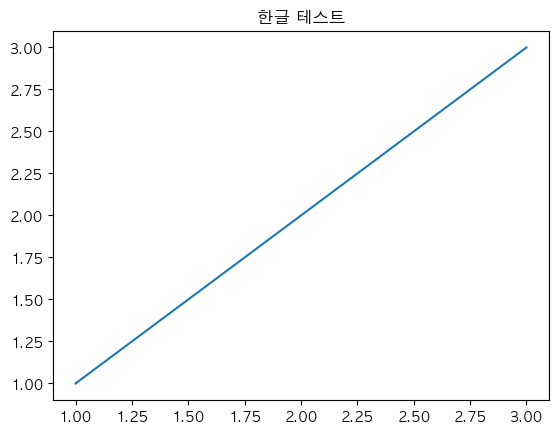

In [25]:
# 1. 폰트 설치
'''
!apt-get update
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm -rf ~/.cache/matplotlib
'''
# 2. (중요) 위 셀 실행 후, "런타임 다시 시작"을 꼭 하기

# 3. 폰트 적용
import matplotlib.pyplot as plt
# plt.rc('font', family='NanumBarunGothic')  # 또는 위에서 확인한 실제 폰트 이름

#맥북용 폰트 설정
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 4. 음수 부호 깨짐 방지
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False

# 5. 한글 테스트
plt.plot([1, 2, 3], [1, 2, 3])
plt.title('한글 테스트')
plt.show()

In [26]:
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
# 텍스트 데이터를 벡터(숫자)의 형태로 바꾸기 위한 TfidfVectorizer를 불러옵니다.
#	TF-IDF는 문서 내 단어의 중요도를 반영해 벡터화합니다.
#	예를 들어, “한국”, “정부”, “데이터” 같은 단어가 얼마나 중요한지를 반영합니다.
from sklearn.metrics.pairwise import cosine_similarity #	유사도는 1에 가까울수록 비슷하고, 0에 가까울수록 다름
import nltk #영어 기준 토큰화, 품사 분석, 불용어 제거 등에 쓰임
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
# y축이나 x축의 숫자 포맷을 사용자 지정 함수로 포매팅(formatting) 할 수 있게 해줍니다.
# 예: 축에 1,000,000이 있으면 1M으로 표시하는 등 변경 가능.

# plt.rc('font', family='NanumBarunGothic')

In [27]:
# 1번 옵션
data = pd.read_csv('/Users/ashmin/Desktop/python workspace/데이터가치인턴/데이터가치평가/국토교통오픈마켓_240624.csv', index_col=0)

In [28]:
# 2번 옵션 (심화)
data = pd.read_csv('/Users/ashmin/Desktop/python workspace/데이터가치인턴/데이터가치평가/KDX+국가교통데이터오픈마켓+해양수산_20250731.csv', index_col=0)

In [29]:
data.iloc[4:10] # 정수기반 인덱싱(행)

,filename,sheet_name,name,description,price,schema,valid,collect_dt,sorted_schema,company,category,extension,tags,대분류,중분류,소분류,tags_list
source,,,,,,,,,,,,,,,,,
bigdata-sea,page_000046.html,-,선박 스케줄 정보,선박의 터미널 입출항 정보\n\n∙선박 입출항시간 분석하는 자료로 활용\n∙하역작업...,1000000,SN|VOYG_NO|SHIP_NM|MS_CD|PRT|SC_ID|BRTH_NM|TRM...,True,2025-07-15,BRTH_NM-EXPECT_ARVL_TM-EXPECT_BRTH_TM-EXPECT_D...,해운항만물류정보협회,해운물류,"CSV, JSON, XML","['물류', '선박', '스케줄', '입출항', '입항시간', '정보', '출항시간...",소비/유통,상품,물류,"['물류', '선박', '스케줄', '입출항', '입항시간', '정보', '출항시간..."
bigdata-sea,page_000048.html,-,해상수출 물류가격 견적데이터,∙2014년부터 2020년까지의 전세계 항구에 대한 해상수출 운임 견적서\n∙출발항...,700000,ESTMT_OFC_NO|ESTMT_YMD|DPTR_PRT_NM|ARVL_PRT_NM...,True,2025-07-15,ARVL_CN_NM-ARVL_PRT_NM-CNTNR_20FT_QTY-CNTNR_40...,울산과학기술원,해운물류,"CSV, JSON, XML","['예상수출물류비용', '예상컨테이너비용', '울산과학기술원', '해상수출', '해...",소비/유통,상품,물류,"['예상수출물류비용', '예상컨테이너비용', '울산과학기술원', '해상수출', '해..."
bigdata-sea,page_000054.html,-,어업별 조업 정보,"3개 어업별 어선의 조업 현황(어구 종류, 양망/투망이력) 정보\n\n∙어업인에게 ...",0,FS_NM|FS_NO|FSH_KIND|BUOY_KND_NM|SOF_NM|FSH_CO...,True,2025-07-15,BUOY_KND_NM-CRRNT_DRCN-CRRNT_SPD-FSHNG_INTRVL-...,광주과학기술원,어업자원,"CSV, JSON, XML","['광주과학기술원', '어구종류', '어선정보', '어업', '어종', '조업현황']",산업/기술,해양/수산,어업,"['광주과학기술원', '어구종류', '어선정보', '어업', '어종', '조업현황']"
bigdata-sea,page_000055.html,-,어업별 어획량 정보,3개 어업별 어선의 조업 결과에 따른 어획량 정보\n\n∙어업별 어획량 통계 자료에...,0,MRN_NO|FSH_KIND|BUOY_KND_NM|SOF_NM|FW_YR|FW_MN...,True,2025-07-15,BUOY_KND_NM-FSH_HL_MNTH-FSH_KIND-FW_MNTH-FW_YR...,광주과학기술원,어업자원,"CSV, JSON, XML","['광주과학기술원', '어구', '어업', '어종', '어획량', '해어황예보']",산업/기술,해양/수산,어업,"['광주과학기술원', '어구', '어업', '어종', '어획량', '해어황예보']"
bigdata-sea,page_000056.html,-,어업별 어구부위 위치,3개 어업별 어구부이(수상) GPS위치\n\n∙조업 어구 실시간 위치 정보제공 서비...,0,FS_NM|FS_NO|FSH_KIND|BUOY_KND_NM|BUOY_CNT|BUOY...,True,2025-07-15,BUOY_CNT-BUOY_ID-BUOY_KND_NM-BUOY_LA-BUOY_LO-B...,광주과학기술원,어업자원,"CSV, JSON, XML","['광주과학기술원', '부이', '어구', '어선', '위치정보', '조업']",산업/기술,해양/수산,어업,"['광주과학기술원', '부이', '어구', '어선', '위치정보', '조업']"
bigdata-sea,page_000057.html,-,어업별 수중어구 위치,3개 어업별 수중어망에 부착된 어구수중위치\n\n∙어업인의 어구자산을 회수할 수 있...,0,FS_NM|FS_NO|FSH_KIND|BUOY_KND_NM|BUOY_CNT|BUOY...,True,2025-07-15,BUOY_CNT-BUOY_ID-BUOY_KND_NM-BUOY_UNIT-FSH_KIN...,광주과학기술원,어업자원,"CSV, JSON, XML","['광주과학기술원', '어구', '어선', '위치정보', '조업', '태그']",산업/기술,해양/수산,어업,"['광주과학기술원', '어구', '어선', '위치정보', '조업', '태그']"


In [30]:
def millions(x, pos):
    return f'{int(x):,}' # 숫자를 천 단위로 콤마(,)를 찍어서 보기 좋게 만드는 함수

In [31]:
# 1번 옵션
# data 데이터프레임에서 "소분류"라는 컬럼(column)을 기준으로 값이 “위치” 인 행(row)들만 True로 표시합니다. (GPS기반 데이터 사용한다는 것)
data_earnings = data[data['소분류'] == '위치데이터'] 

In [32]:
# data_earnings 데이터프레임에서 상위 5개 행(row) 를 출력합니다. (예시)
data_earnings.head() 

,filename,sheet_name,name,description,price,schema,valid,collect_dt,sorted_schema,company,category,extension,tags,대분류,중분류,소분류,tags_list
source,,,,,,,,,,,,,,,,,
bigdata-transportation,definition_20110.xlsx,경주시 BIS 버스 이벤트 로그,경주시 BIS 버스 이벤트 로그,"경주시 버스 정류장 도착 및 출발 정보 데이터입니다. 승차 및 하차 시각, 정차시간...",0,컬럼명(한글)|이벤트시각|노선명|노선설명|정류장도착시각|정류장출발시각|정차시간(초)...,True,2025-07-15,노선명-노선설명-운행구분-이벤트구분-이벤트시각-정류장 GPS X-정류장 GPS Y-...,포항테크노파크,버스,CSV / ZIP,"['포항테크노파크', '교통', '경주', '버스', '정류장', '정류장도착시각'...",공간/위치,위치기반,위치데이터,"['포항테크노파크', '교통', '경주', '버스', '정류장', '정류장도착시각'..."
bigdata-transportation,definition_20388.xlsx,데이터셋 명세서(아파트 단지별 도로혼잡빈도 정보),아파트 단지별 도로혼잡빈도 정보,아파트 단지별로 차량의 혼잡 정도를 나타내는 교통정보인 도로혼잡빈도를 확인할 수 있...,0,컬럼명(한글)|아파트단지코드|아파트단지명|필지고유번호|지번주소|도로명관리번호|사용승...,True,2025-07-15,도로명관리번호-동수-링크수-사용승인일-세대수-아파트단지명-아파트단지코드-지번주소-최...,한국부동산원,융합,CSV / ZIP,"['아파트', '단지', '주요도로망', '도로혼잡빈도', '링크', '혼잡', '...",공간/위치,위치기반,위치데이터,"['아파트', '단지', '주요도로망', '도로혼잡빈도', '링크', '혼잡', '..."
bigdata-transportation,definition_20272.xlsx,길단위_버스 이용 접근성,길단위 버스 이용 접근성,도로 형상정보를 중심으로 버스 정류장까지의 거리를 계산·가공하여 정의된 버스 이용 접근성,0,컬럼명(한글)|시도코드|시도명|시군구코드|시군구명|도로명|도로번호|도로길이|버스이용...,True,2025-07-15,도로길이-도로명-도로번호-버스이용접근성-시군구명-시군구코드-시도명-시도코드-컬럼명(...,오픈메이트,융합,CSV / ZIP,"['길', '도로', '상권분석', '교통', '대중교통', '버스', '버스 정류...",공간/위치,위치기반,위치데이터,"['길', '도로', '상권분석', '교통', '대중교통', '버스', '버스 정류..."
bigdata-transportation,definition_20322.xlsx,데이터셋 명세서(스쿨존 단독주택 주차장 정보),스쿨존 단독주택 주차장 정보,수도권 내 어린이보호구역에 접한 단독주택을 대상으로 한 주변 주차장 정보,0,컬럼명(한글)|필지고유번호|시군구코드|읍면동리코드|지번구분|본번|부번|지번주소|인근...,True,2025-07-15,본번-부번-시군구코드-요금 구분-읍면동리코드-인근 주차장 순번-인근 주차장수-주차단...,한국도로공사,시설·안전,CSV / ZIP,"['도로', '염수', '탱크', '밸브', '분사']",공간/위치,위치기반,위치데이터,"['도로', '염수', '탱크', '밸브', '분사']"
bigdata-transportation,definition_20274.xlsx,길단위_골목상권,길단위 집객시설 이용 접근성,도로 형상정보를 중심으로 각 집객시설과의 거리를 계산·가공하여 정의된 집객시설 이용...,0,컬럼명(한글)|시도코드|시도명|시군구코드|시군구명|도로명|도로번호|도로길이|전통시장...,True,2025-07-15,고등학교접근성-대형마트접근성-대형쇼핑몰접근성-도로길이-도로명-도로번호-도서관접근성-...,오픈메이트,융합,CSV / ZIP,"['길', '도로', '상권분석', '집객시설', '접근성', '거리', '전국',...",공간/위치,위치기반,위치데이터,"['길', '도로', '상권분석', '집객시설', '접근성', '거리', '전국',..."


TypeError: unsupported operand type(s) for -: 'str' and 'int'

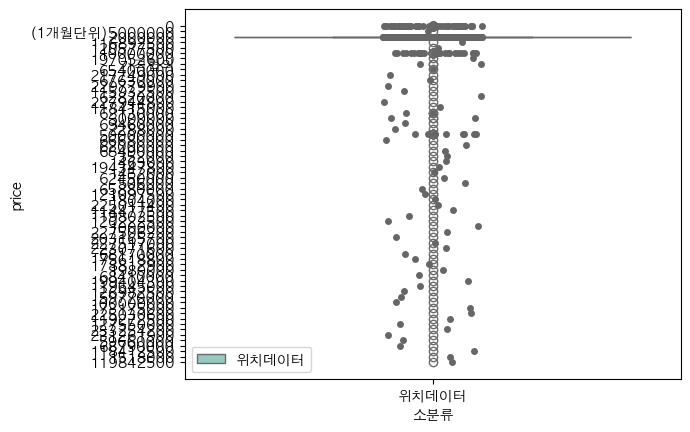

In [33]:
# * 수정본
# 위치 기반 데이터들의 금액 분포를 박스플롯과 스트립플롯으로 시각화합니다.
# 박스플롯은 데이터의 분포를 보여주고, 스트립플롯은 개별 데이터 포인트를 표시합니다.
# 또한, 각 소분류의 최소값, 최대값, 평균, 중앙값을 표시합니다.
# 1. 카테고리 정렬 기준 만들기
sorted_categories = data_earnings['소분류'].value_counts().index

# 2. 박스플롯 + 스트립플롯
ax = sns.boxplot(x='소분류', y='price', data=data_earnings, hue='소분류', legend=True, palette='Set3')
sns.stripplot(x="소분류", y="price", data=data_earnings, jitter=True, color="0.4")

# 3. Min/Max (왼쪽에 배치)
mins = data_earnings.groupby('소분류')['price'].min()
maxs = data_earnings.groupby('소분류')['price'].max()
x_coords = np.arange(len(mins))
for x, min_val, max_val in zip(x_coords, mins[sorted_categories], maxs[sorted_categories]):
    ax.text(x - 0.2, min_val - 2, f'Min: {min_val:,}', ha='right', va='top', fontsize=10, color='gray')
    ax.text(x - 0.2, max_val + 2, f'Max: {max_val:,}', ha='right', va='bottom', fontsize=10, color='gray')

# 4. Count 표시 (중앙)
counts = data_earnings['소분류'].value_counts()
for x, cat in enumerate(sorted_categories):
    count = counts[cat]
    ax.text(x, 0.02, f'Count: {count}', ha='center', va='bottom',
            transform=ax.get_xaxis_transform(), fontsize=9, color='black')

# 5. Mean (오른쪽 위)
means = data_earnings.groupby('소분류')['price'].mean()
for x, mean in enumerate(means[sorted_categories]):
    ax.text(x + 0.2, mean + 2, f'Mean: {mean:,.0f}', ha='left', va='bottom', fontsize=10, color='blue')

# 6. Median (오른쪽 아래)
medians = data_earnings.groupby('소분류')['price'].median()
for x, median in enumerate(medians[sorted_categories]):
    ax.text(x + 0.2, median - 2, f'Median: {median:,.0f}', ha='left', va='top', fontsize=10, color='green')

# 7. 폰트 및 y축 설정
# plt.rc('font', family='NanumBarunGothic')
# 맥북용 폰트 설정
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

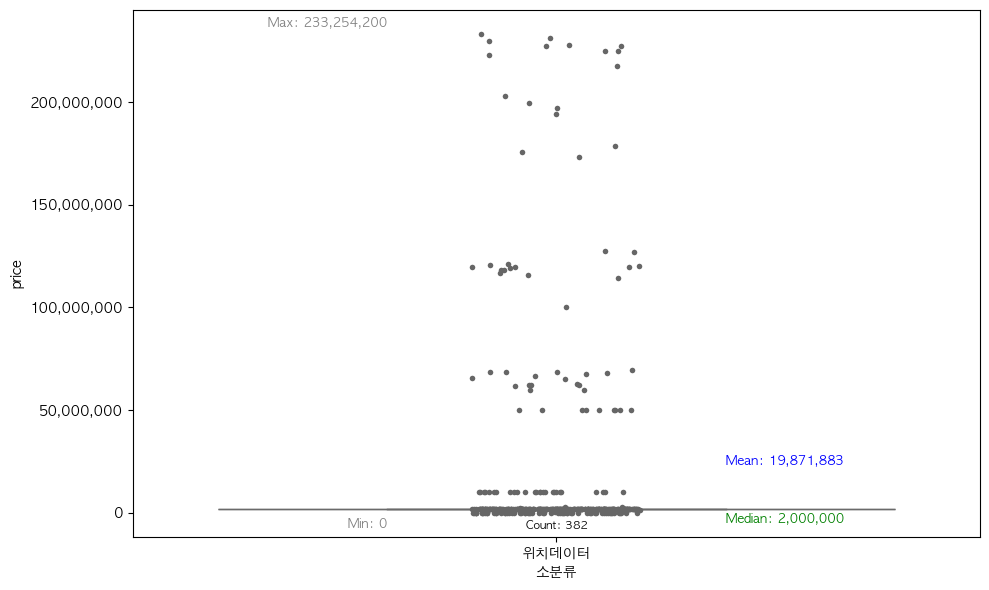

In [38]:
# * 수정본
# 위치 기반 데이터들의 금액 분포를 박스플롯과 스트립플롯으로 시각화합니다.
# 박스플롯은 데이터의 분포를 보여주고, 스트립플롯은 개별 데이터 포인트를 표시합니다.
# 또한, 각 소분류의 최소값, 최대값, 평균, 중앙값을 표시합니다.

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ─── 0. price 컬럼 전처리 및 필터링 ─────────────────────────────────────────
# 1) 문자열로 변환 후 콤마 제거
price_str = data_earnings['price'].astype(str).str.replace(',', '', regex=False)
# 2) 정수/소수점만 허용하는 패턴 매칭
mask = price_str.str.match(r'^\d+(\.\d+)?$')
# 3) 숫자인 행만 남기고 float 변환
data_earnings = data_earnings[mask].copy()
data_earnings['price'] = price_str[mask].astype(float)

# ─── 1. 카테고리 정렬 기준 만들기 ───────────────────────────────────────────────
sorted_categories = data_earnings['소분류'].value_counts().index

# ─── 2. y축 포맷터 함수 정의 ────────────────────────────────────────────────────
def millions(x, pos):
    return f'{int(x):,}'

# ─── 3. 박스플롯 + 스트립플롯 그리기 ────────────────────────────────────────────
plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    x='소분류',
    y='price',
    data=data_earnings,
    hue='소분류',
    palette='Set3',
    dodge=False,
    showfliers=False
)
sns.stripplot(
    x='소분류',
    y='price',
    data=data_earnings,
    jitter=True,
    color='0.4',
    size=4,
    ax=ax,
    dodge=False
)

# ─── 4. Min / Max 표시 (왼쪽) ───────────────────────────────────────────────────
mins = data_earnings.groupby('소분류')['price'].min()
maxs = data_earnings.groupby('소분류')['price'].max()
global_max = maxs.max()
for x, cat in enumerate(sorted_categories):
    min_val = mins[cat]
    max_val = maxs[cat]
    ax.text(
        x - 0.2, min_val - global_max * 0.01,
        f'Min: {min_val:,.0f}',
        ha='right', va='top',
        fontsize=9, color='gray'
    )
    ax.text(
        x - 0.2, max_val + global_max * 0.01,
        f'Max: {max_val:,.0f}',
        ha='right', va='bottom',
        fontsize=9, color='gray'
    )

# ─── 5. Count 표시 (중앙) ───────────────────────────────────────────────────────
counts = data_earnings['소분류'].value_counts()
for x, cat in enumerate(sorted_categories):
    ax.text(
        x, 0.01,
        f'Count: {counts[cat]}',
        ha='center', va='bottom',
        transform=ax.get_xaxis_transform(),
        fontsize=8, color='black'
    )

# ─── 6. Mean 표시 (오른쪽 위) ─────────────────────────────────────────────────
means = data_earnings.groupby('소분류')['price'].mean()
for x, cat in enumerate(sorted_categories):
    mean_val = means[cat]
    ax.text(
        x + 0.2, mean_val + global_max * 0.01,
        f'Mean: {mean_val:,.0f}',
        ha='left', va='bottom',
        fontsize=9, color='blue'
    )

# ─── 7. Median 표시 (오른쪽 아래) ───────────────────────────────────────────────
medians = data_earnings.groupby('소분류')['price'].median()
for x, cat in enumerate(sorted_categories):
    med_val = medians[cat]
    ax.text(
        x + 0.2, med_val - global_max * 0.01,
        f'Median: {med_val:,.0f}',
        ha='left', va='top',
        fontsize=9, color='green'
    )

# ─── 8. 한글 폰트 및 y축 설정 ───────────────────────────────────────────────────
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False
ax.yaxis.set_major_formatter(FuncFormatter(millions))

# ─── 9. 범례 숨기기 및 레이아웃 조정 ───────────────────────────────────────────
plt.legend([], [], frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


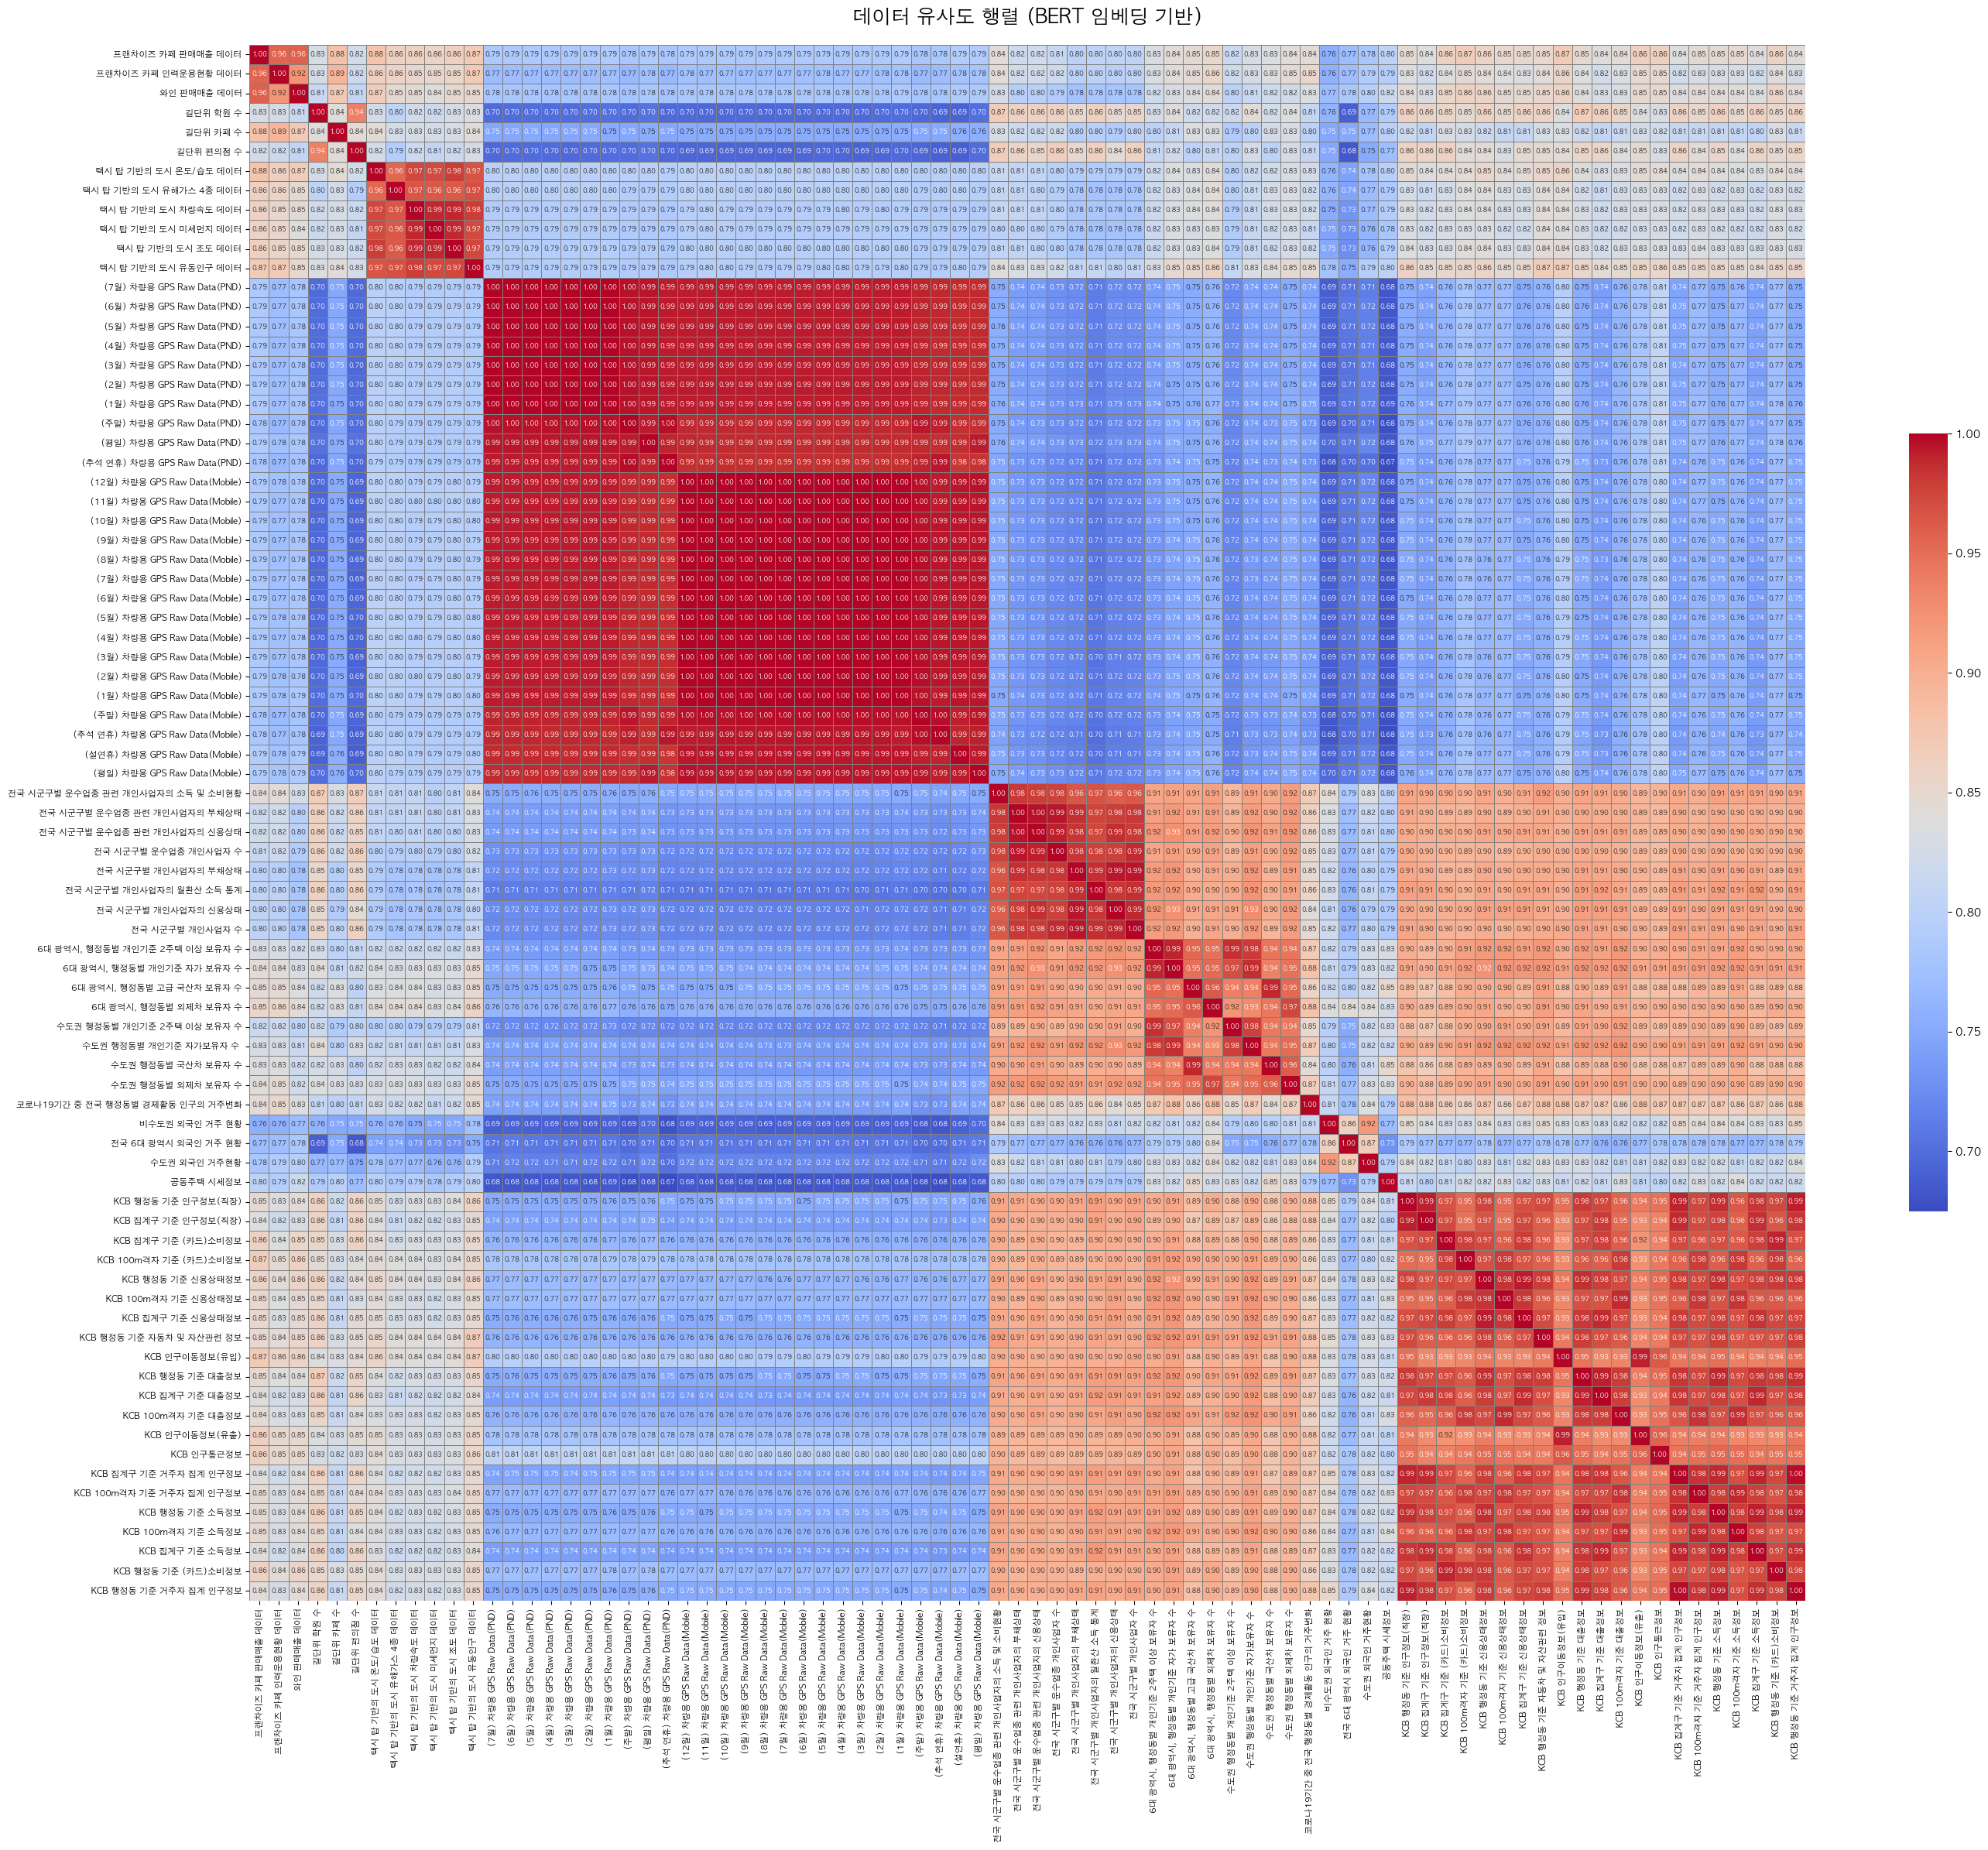

In [ ]:
# 대형 데이터는 불가능
# 1. 데이터 불러오기 (index_col=0 사용)
data = pd.read_csv('./데이터가치인턴/데이터가치평가/국토교통오픈마켓_240624.csv', index_col=0)

# 2. "데이터명+설명" 결합 (임베딩용)
data['data_text'] = data['데이터명'].astype(str) + ' ' + data['설명'].astype(str)

# 3. 임베딩 대상(문장)과 축 라벨(데이터명) 추출
data_texts = data['data_text'].tolist()         # 임베딩 입력
data_names = data['데이터명'].tolist()           # 라벨 (표 축에만 사용) 이거는 전체 데이터
# data_names = data_earnings['데이터명'].tolist()  # 소분류가 '위치'인 데이터의 데이터명만 추출

# 4. BERT 모델 로드
model_name = "snunlp/KR-BERT-char16424"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# 5. 임베딩 추출 함수
def get_sentence_embedding(sentence):
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze()

# 6. 임베딩 계산 (진짜로 "데이터명+설명" 전체 문장에 대해!)
embeddings = [get_sentence_embedding(text).numpy() for text in data_texts]

# 7. 유사도 행렬 계산 및 DataFrame 변환 (라벨은 "데이터명"만!)
similarity_matrix = cosine_similarity(embeddings)
similarity_df = pd.DataFrame(similarity_matrix, index=data_names, columns=data_names)

#폰트 설정
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False
'''
# 8. Heatmap 시각화
plt.figure(figsize=(20, 16))
ax = sns.heatmap(
    similarity_df,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"shrink": 0.5},
    square=True
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.title('Data Name Similarity Matrix (using BERT: Name+Desc Embedding)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()
'''
# 8. Heatmap 시각화
plt.figure(figsize=(30, 24))  # 가로·세로 크기를 더 키움 (글자 겹침 방지)

ax = sns.heatmap(
    similarity_df,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6, "ha": "center", "va": "center"},  # 수직·수평 정렬 중앙으로
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"shrink": 0.5},
    square=True
)

# 축 레이블 글씨 크기와 회전 조정
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.title('데이터 유사도 행렬 (BERT 임베딩 기반)', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


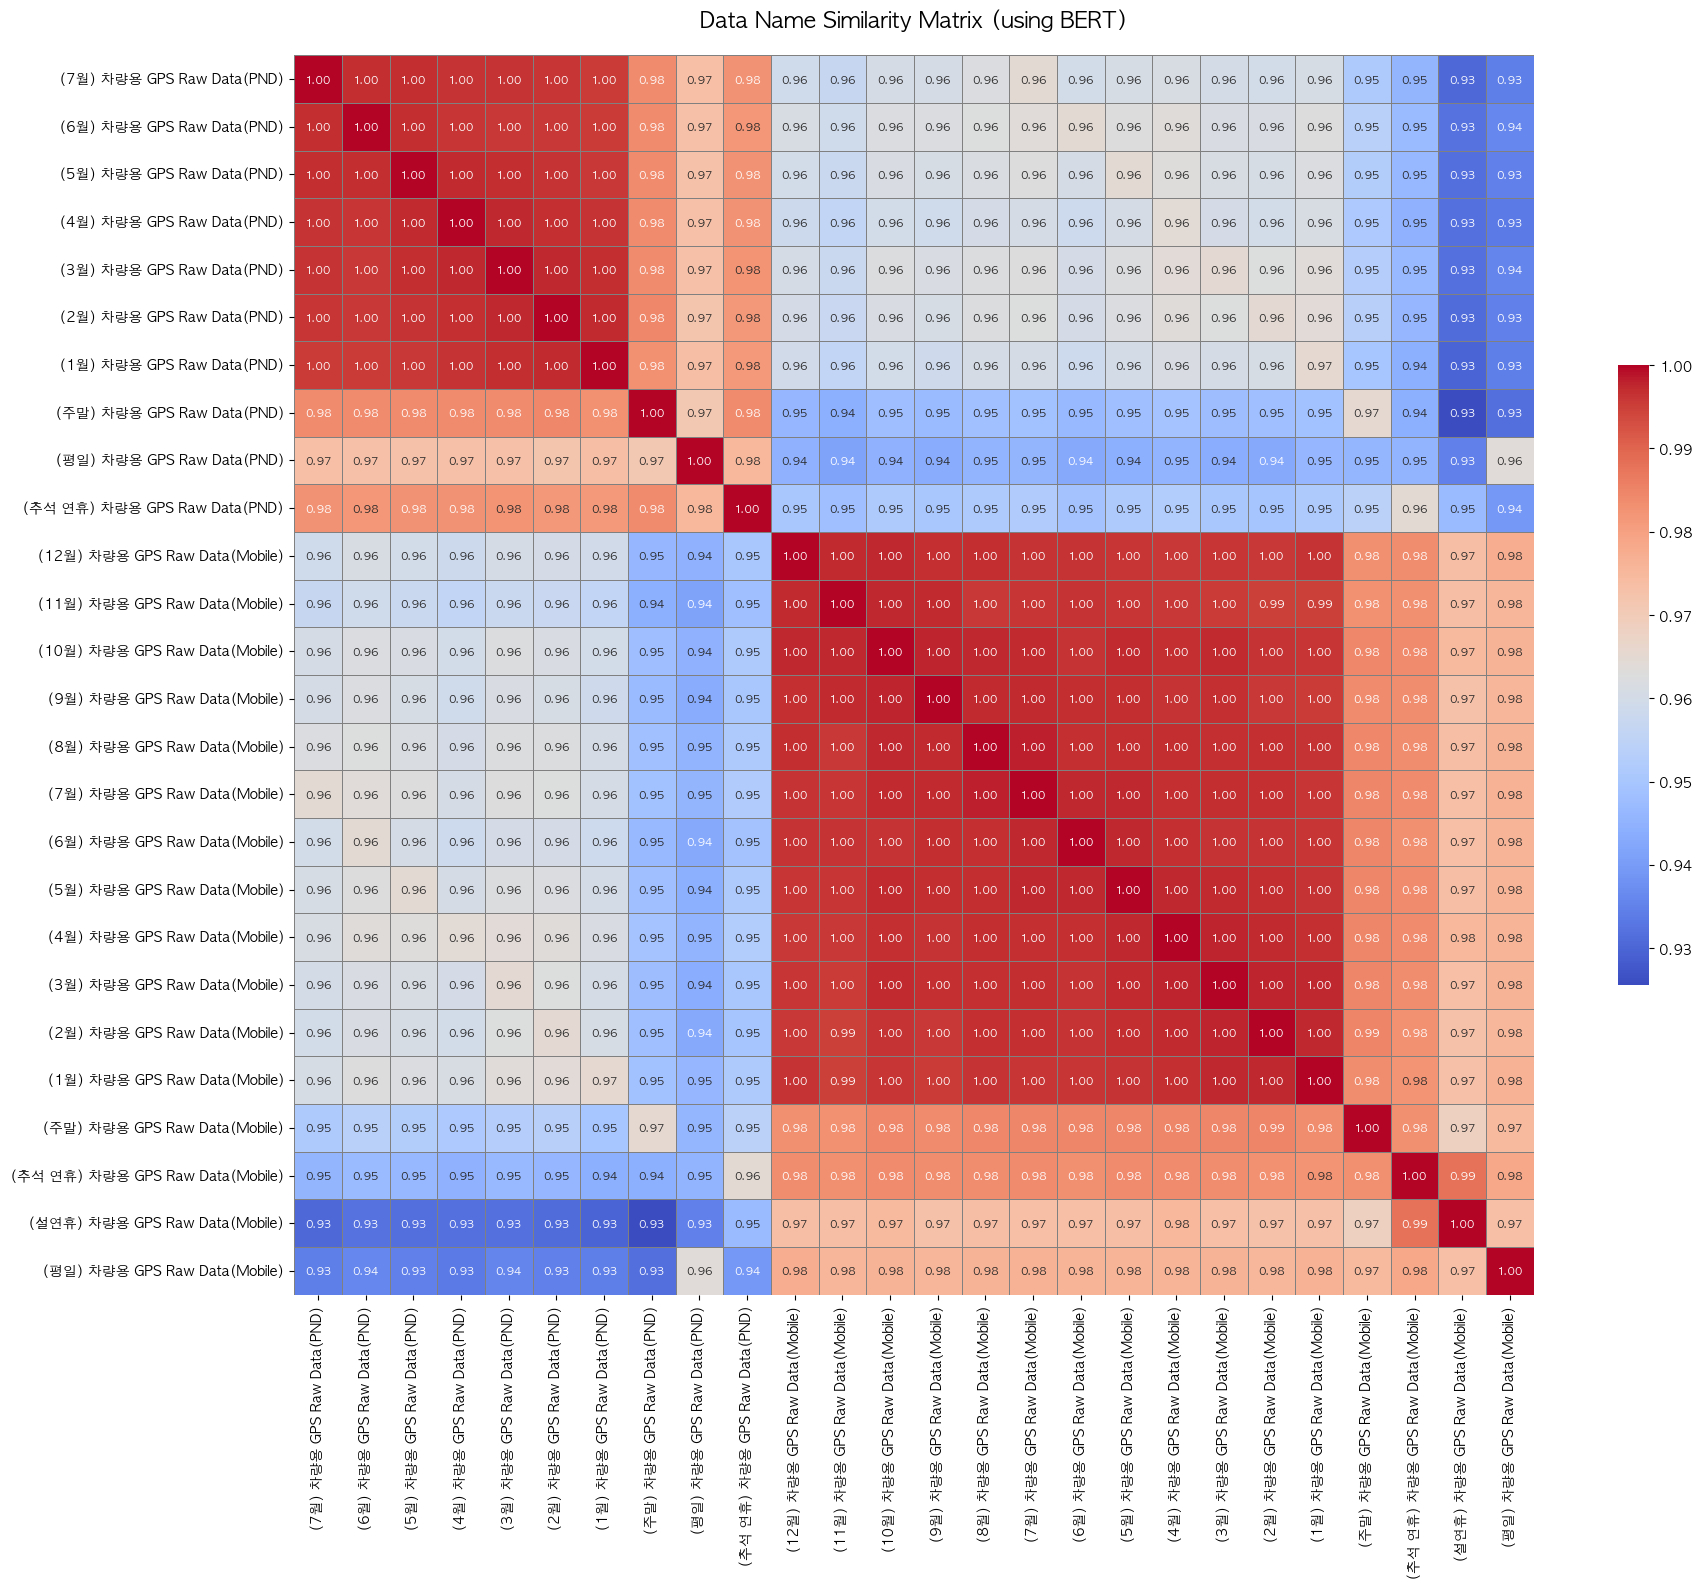

In [11]:
model_name = "snunlp/KR-BERT-char16424"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

data['data_text'] = data['데이터명'].astype(str) + ' ' + data['설명'].astype(str) # 데이터명과 설명을 합쳐서 하나의 텍스트로 만들어 임베딩 추출에 사용

# 문장 임베딩 추출 함수
def get_sentence_embedding(sentence):
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze()

# 데이터명 리스트
data_names = data_earnings['데이터명'].tolist()  # 소분류가 '위치'인 데이터의 데이터명만 추출

# 각 데이터명의 임베딩 추출
embeddings = [get_sentence_embedding(name).numpy() for name in data_names]

# 유사도 행렬 계산
similarity_matrix = cosine_similarity(embeddings)

# 유사도 행렬을 데이터프레임으로 변환
similarity_df = pd.DataFrame(similarity_matrix, index=data_names, columns=data_names)

# 유사도 행렬 시각화
plt.figure(figsize=(20, 16))

# 맥북용 폰트 설정
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2) Heatmap 옵션으로 간격·테두리·컬러바 크기 조정
ax = sns.heatmap(
    similarity_df,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",                # 소수점 자리수 2째 자리 까지로 세팅
    annot_kws={"size": 8},    # annotation 폰트 크기
    linewidths=0.5,           # 셀 사이 테두리 두께
    linecolor='gray',         # 테두리 색
    cbar_kws={"shrink": 0.5}, # 컬러바 크기 축소
    square=True               # 정사각형 셀
)

# 3) 축 레이블 크기와 회전 각도 조정
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

# 4) 타이틀 및 레이아웃 조정
plt.title('Data Name Similarity Matrix (using BERT)', fontsize=16, pad=20)
plt.tight_layout()  # 여백 자동 조정

plt.show()

In [39]:
# 확장된 데이터셋에 대한 임베딩을 추출하고 저장하는 코드 
# ──────────────────────────────────────────────────
# 셀 1: 전체 데이터 임베딩 (1회만 실행) 약 13분 45초 소요
# ──────────────────────────────────────────────────

import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel

# 데이터 로드
data = pd.read_csv('/Users/ashmin/Desktop/python workspace/데이터가치인턴/데이터가치평가/KDX+국가교통데이터오픈마켓+해양수산_20250731.csv', index_col=0)
data.fillna("", inplace=True)
data["full_text"] = data["name"] + " " + data["description"] + " " + data["sorted_schema"]

# KR-BERT 모델 로드
tokenizer = AutoTokenizer.from_pretrained("snunlp/KR-BERT-char16424")
model = AutoModel.from_pretrained("snunlp/KR-BERT-char16424")
model.eval()

def get_embedding(text):
    tokens = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        out = model(**tokens)
    return out.last_hidden_state.mean(dim=1).squeeze().numpy()

# 전체 임베딩
emb_list = [get_embedding(t) for t in data["full_text"]]
emb_matrix = np.vstack(emb_list)

# 저장
np.save("emb_matrix.npy", emb_matrix)
data[["name", "description", "price", "collect_dt"]].to_csv("data_meta.csv", index=False)
print("✅ 전체 임베딩 완료, emb_matrix.npy & data_meta.csv 저장됨")

KeyboardInterrupt: 

In [42]:
# ──────────────────────────────────────────────────
# 셀 1: 전체 데이터 임베딩 (1회만 실행) batch = 16 사용 version 약 4분 40초 소요
# ──────────────────────────────────────────────────

import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel

# 1) 데이터 로드 및 전처리
data_path = "/Users/ashmin/Desktop/python workspace/데이터가치인턴/데이터가치평가/KDX+국가교통데이터오픈마켓+해양수산_20250731.csv"
data = pd.read_csv(data_path, index_col=0)
data.fillna("", inplace=True)
data["full_text"] = data["name"] + " " + data["description"] + " " + data["sorted_schema"] + " " + data["tags"]

# 2) KR-BERT 모델 로드 & device 설정 (MPS or CPU)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("snunlp/KR-BERT-char16424")
model = AutoModel.from_pretrained("snunlp/KR-BERT-char16424").to(device)
model.eval()

# 3) 임베딩 함수 정의
def get_embedding(text: str) -> np.ndarray:
    toks = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )
    toks = {k: v.to(device) for k, v in toks.items()}
    with torch.no_grad():
        out = model(**toks)
    # 평균 풀링 & CPU 반환
    return out.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()

# 4) 배치 단위 임베딩 수행
batch_size = 16
embeddings_list = []
n = len(data)
print(f"전체 {n}개 데이터 임베딩 시작 (batch_size={batch_size})...")
for start in range(0, n, batch_size):
    end = min(start + batch_size, n)
    batch_texts = data["full_text"].iloc[start:end].tolist()
    batch_embs = [get_embedding(txt) for txt in batch_texts]
    embeddings_list.append(np.vstack(batch_embs))

emb_matrix = np.vstack(embeddings_list)
print("✅ 임베딩 완료")

# 5) 임베딩 및 메타데이터 저장
np.save("emb_matrix.npy", emb_matrix)
data[["name", "description", "price", "collect_dt"]].to_csv("data_meta2.csv", index=False)
print("✅ emb_matrix.npy 및 data_meta2.csv 파일 생성됨")

전체 22378개 데이터 임베딩 시작 (batch_size=16)...
✅ 임베딩 완료
✅ emb_matrix.npy 및 data_meta2.csv 파일 생성됨



✅ 유사도 0.9 이상인 데이터셋 (총 65건):
                                               name  \
7399      [식품_라면/즉석밥/통조림 등] 성별,연령대별 온라인 소비데이터와 구매행태   
15081  [지역별 소비 행태/서울시] 성별,연령대별 온라인 소비행태와 제품별 구매 데이터   
9212       [콘솔 게임기/게임] 성별,연령대별 온라인 소비행태와 제품별 구매 데이터   
18461             [비데] 성별,연령대별, 제품별 온라인 구매데이터와 소비행태   
10369        [즉석식품/통조림류] 성별/연령별/제품별 온라인 구매추이와 소비데이터   
...                                             ...   
9605           [김치냉장고] 성별, 연령별, 제품별 온라인 구매추이와 소비데이터   
17294        [블루투스 스피커/오디오] 성별,연령대별 온라인 구매데이터와 소비행태   
3306           [태블릿PC] 성별,연령대별 온라인 소비행태와 제품별 구매 데이터   
21519          [패션_가방/캐리어] 성별, 연령대별 온라인 쇼핑데이터와 소비행태   
1376                  [캠핑용품] 성별,연령대별 제품 구매데이터와 소비행태   

                                             description price  collect_dt  \
7399   온라인 시장 동향 파악을 위한 이커머스 소비 데이터입니다.\n연령,성별,지역 등 구...  가격협의  2025-07-15   
15081  온라인 시장 동향 파악을 위한 이커머스 소비 데이터입니다.\n연령,성별,지역 등 구...  가격협의  2025-07-15   
9212   온라인 시장 동향 파악을 위한 이커머스 소비 데이터입니다.\n연령,성별,지역 등 구...  가격협의  2025-07-15  

/var/folders/xk/8c55vpcx0494_qk4j8_dj3zh0000gn/T/ipykernel_29507/67494686.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=res, x='similarity', y='name', palette='viridis')


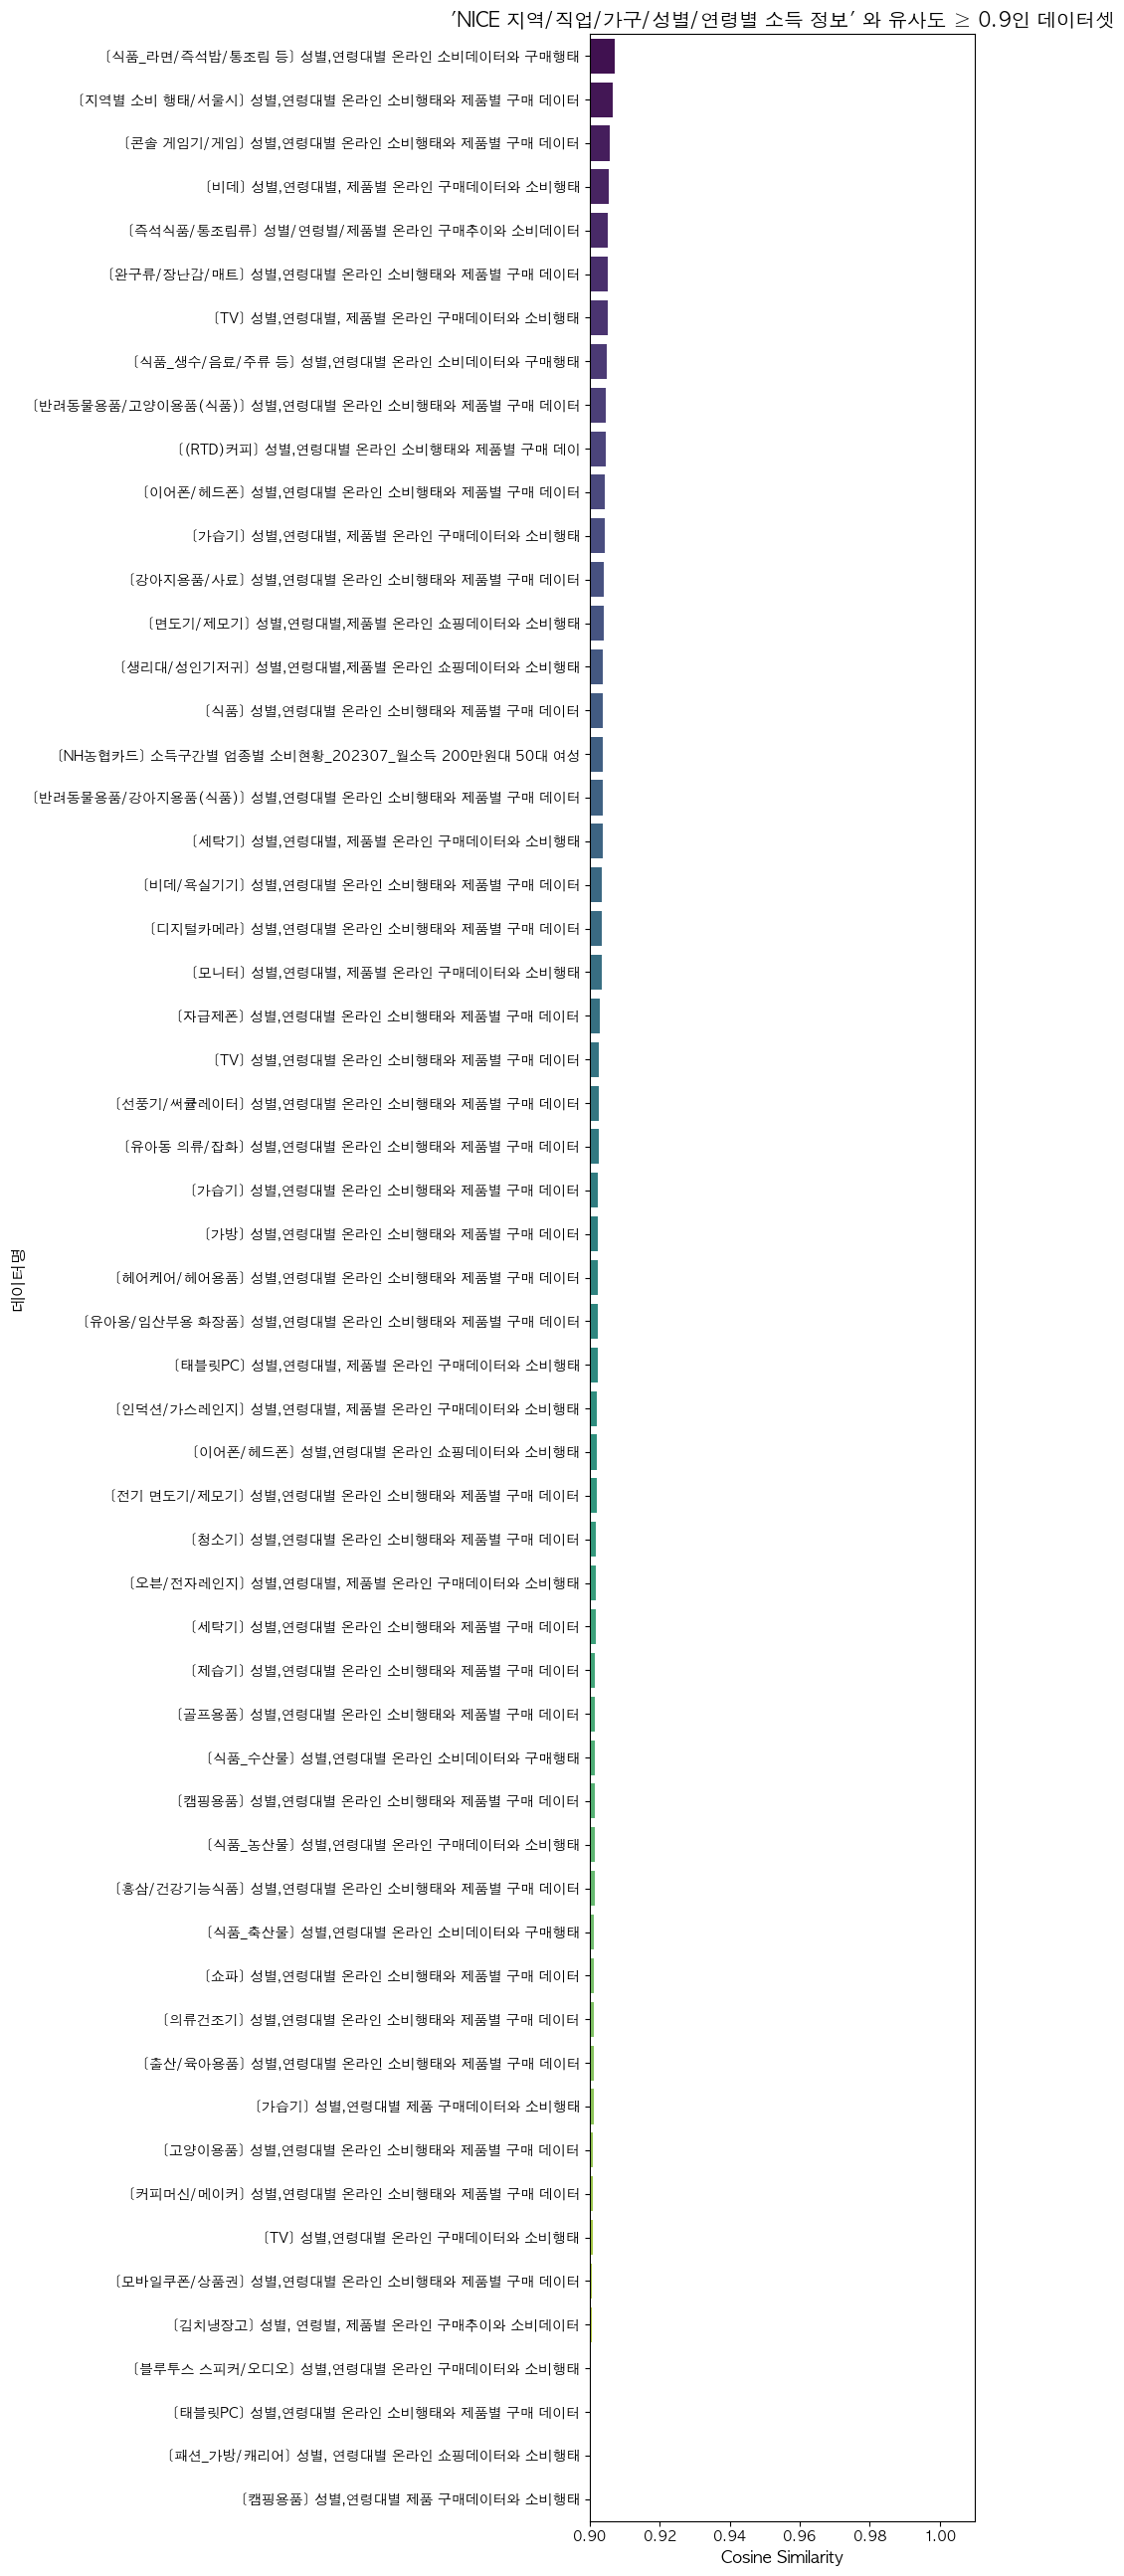

In [43]:
# ──────────────────────────────────────────────────
# 셀 2: 신규 텍스트 임베딩 → 기존 임베딩과 유사도 계산
# ──────────────────────────────────────────────────

import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# 1) 저장된 메타 & 임베딩 로드
data = pd.read_csv("data_meta.csv")
emb_matrix = np.load("emb_matrix.npy")

# 2) KR-BERT 모델 로드
tokenizer = AutoTokenizer.from_pretrained("snunlp/KR-BERT-char16424")
model = AutoModel.from_pretrained("snunlp/KR-BERT-char16424")
model.eval()

# 3) 신규 텍스트 임베딩 함수
def get_embedding(text):
    tokens = tokenizer(text, return_tensors="pt",
                       truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        out = model(**tokens)
    return out.last_hidden_state.mean(dim=1).squeeze().numpy()

# 4) 신규 데이터 입력 및 임베딩
new_name = "NICE 지역/직업/가구/성별/연령별 소득 정보"
new_desc = ("지역·직업·가구·성별·연령 등 다양한 인구학적 특성을 기반으로 "
            "소득 정보를 제공하며, 시군구부터 집계구 단위까지 세밀한 "
            "소득 수준 분석이 가능")
new_text = new_name + " " + new_desc
new_emb = get_embedding(new_text).reshape(1, -1)

# 5) 유사도 계산 및 필터링
sims = cosine_similarity(new_emb, emb_matrix)[0]
data["similarity"] = sims
threshold = 0.90 # 유사도 임계치 설정 (변경 가능)
res = data[data["similarity"] >= threshold] \
         .sort_values("similarity", ascending=False)

# 6) 결과 출력 및 시각화
if not res.empty:
    print(f"\n✅ 유사도 {threshold} 이상인 데이터셋 (총 {len(res)}건):")
    print(res[['name', 'description', 'price', 'collect_dt', 'similarity']])

    plt.figure(figsize=(10, max(4, 0.4 * len(res))))
    sns.barplot(data=res, x='similarity', y='name', palette='viridis')
    plt.title(f"'{new_name}' 와 유사도 ≥ {threshold}인 데이터셋", fontsize=14)
    plt.xlabel('Cosine Similarity', fontsize=12)
    plt.ylabel('데이터명', fontsize=12)
    plt.xlim(threshold, 1.01)
    plt.tight_layout()
    plt.show()
else:
    print("❗ 유사도 기준 이상의 데이터셋이 없습니다.")


 유사도 0.9 이상인 데이터셋 (총 65건):
                                               name  \
7399      [식품_라면/즉석밥/통조림 등] 성별,연령대별 온라인 소비데이터와 구매행태   
15081  [지역별 소비 행태/서울시] 성별,연령대별 온라인 소비행태와 제품별 구매 데이터   
9212       [콘솔 게임기/게임] 성별,연령대별 온라인 소비행태와 제품별 구매 데이터   
18461             [비데] 성별,연령대별, 제품별 온라인 구매데이터와 소비행태   
10369        [즉석식품/통조림류] 성별/연령별/제품별 온라인 구매추이와 소비데이터   
...                                             ...   
9605           [김치냉장고] 성별, 연령별, 제품별 온라인 구매추이와 소비데이터   
17294        [블루투스 스피커/오디오] 성별,연령대별 온라인 구매데이터와 소비행태   
3306           [태블릿PC] 성별,연령대별 온라인 소비행태와 제품별 구매 데이터   
21519          [패션_가방/캐리어] 성별, 연령대별 온라인 쇼핑데이터와 소비행태   
1376                  [캠핑용품] 성별,연령대별 제품 구매데이터와 소비행태   

                                             description price  collect_dt  \
7399   온라인 시장 동향 파악을 위한 이커머스 소비 데이터입니다.\n연령,성별,지역 등 구...  가격협의  2025-07-15   
15081  온라인 시장 동향 파악을 위한 이커머스 소비 데이터입니다.\n연령,성별,지역 등 구...  가격협의  2025-07-15   
9212   온라인 시장 동향 파악을 위한 이커머스 소비 데이터입니다.\n연령,성별,지역 등 구...  가격협의  2025-07-15   

/var/folders/xk/8c55vpcx0494_qk4j8_dj3zh0000gn/T/ipykernel_29507/927285818.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


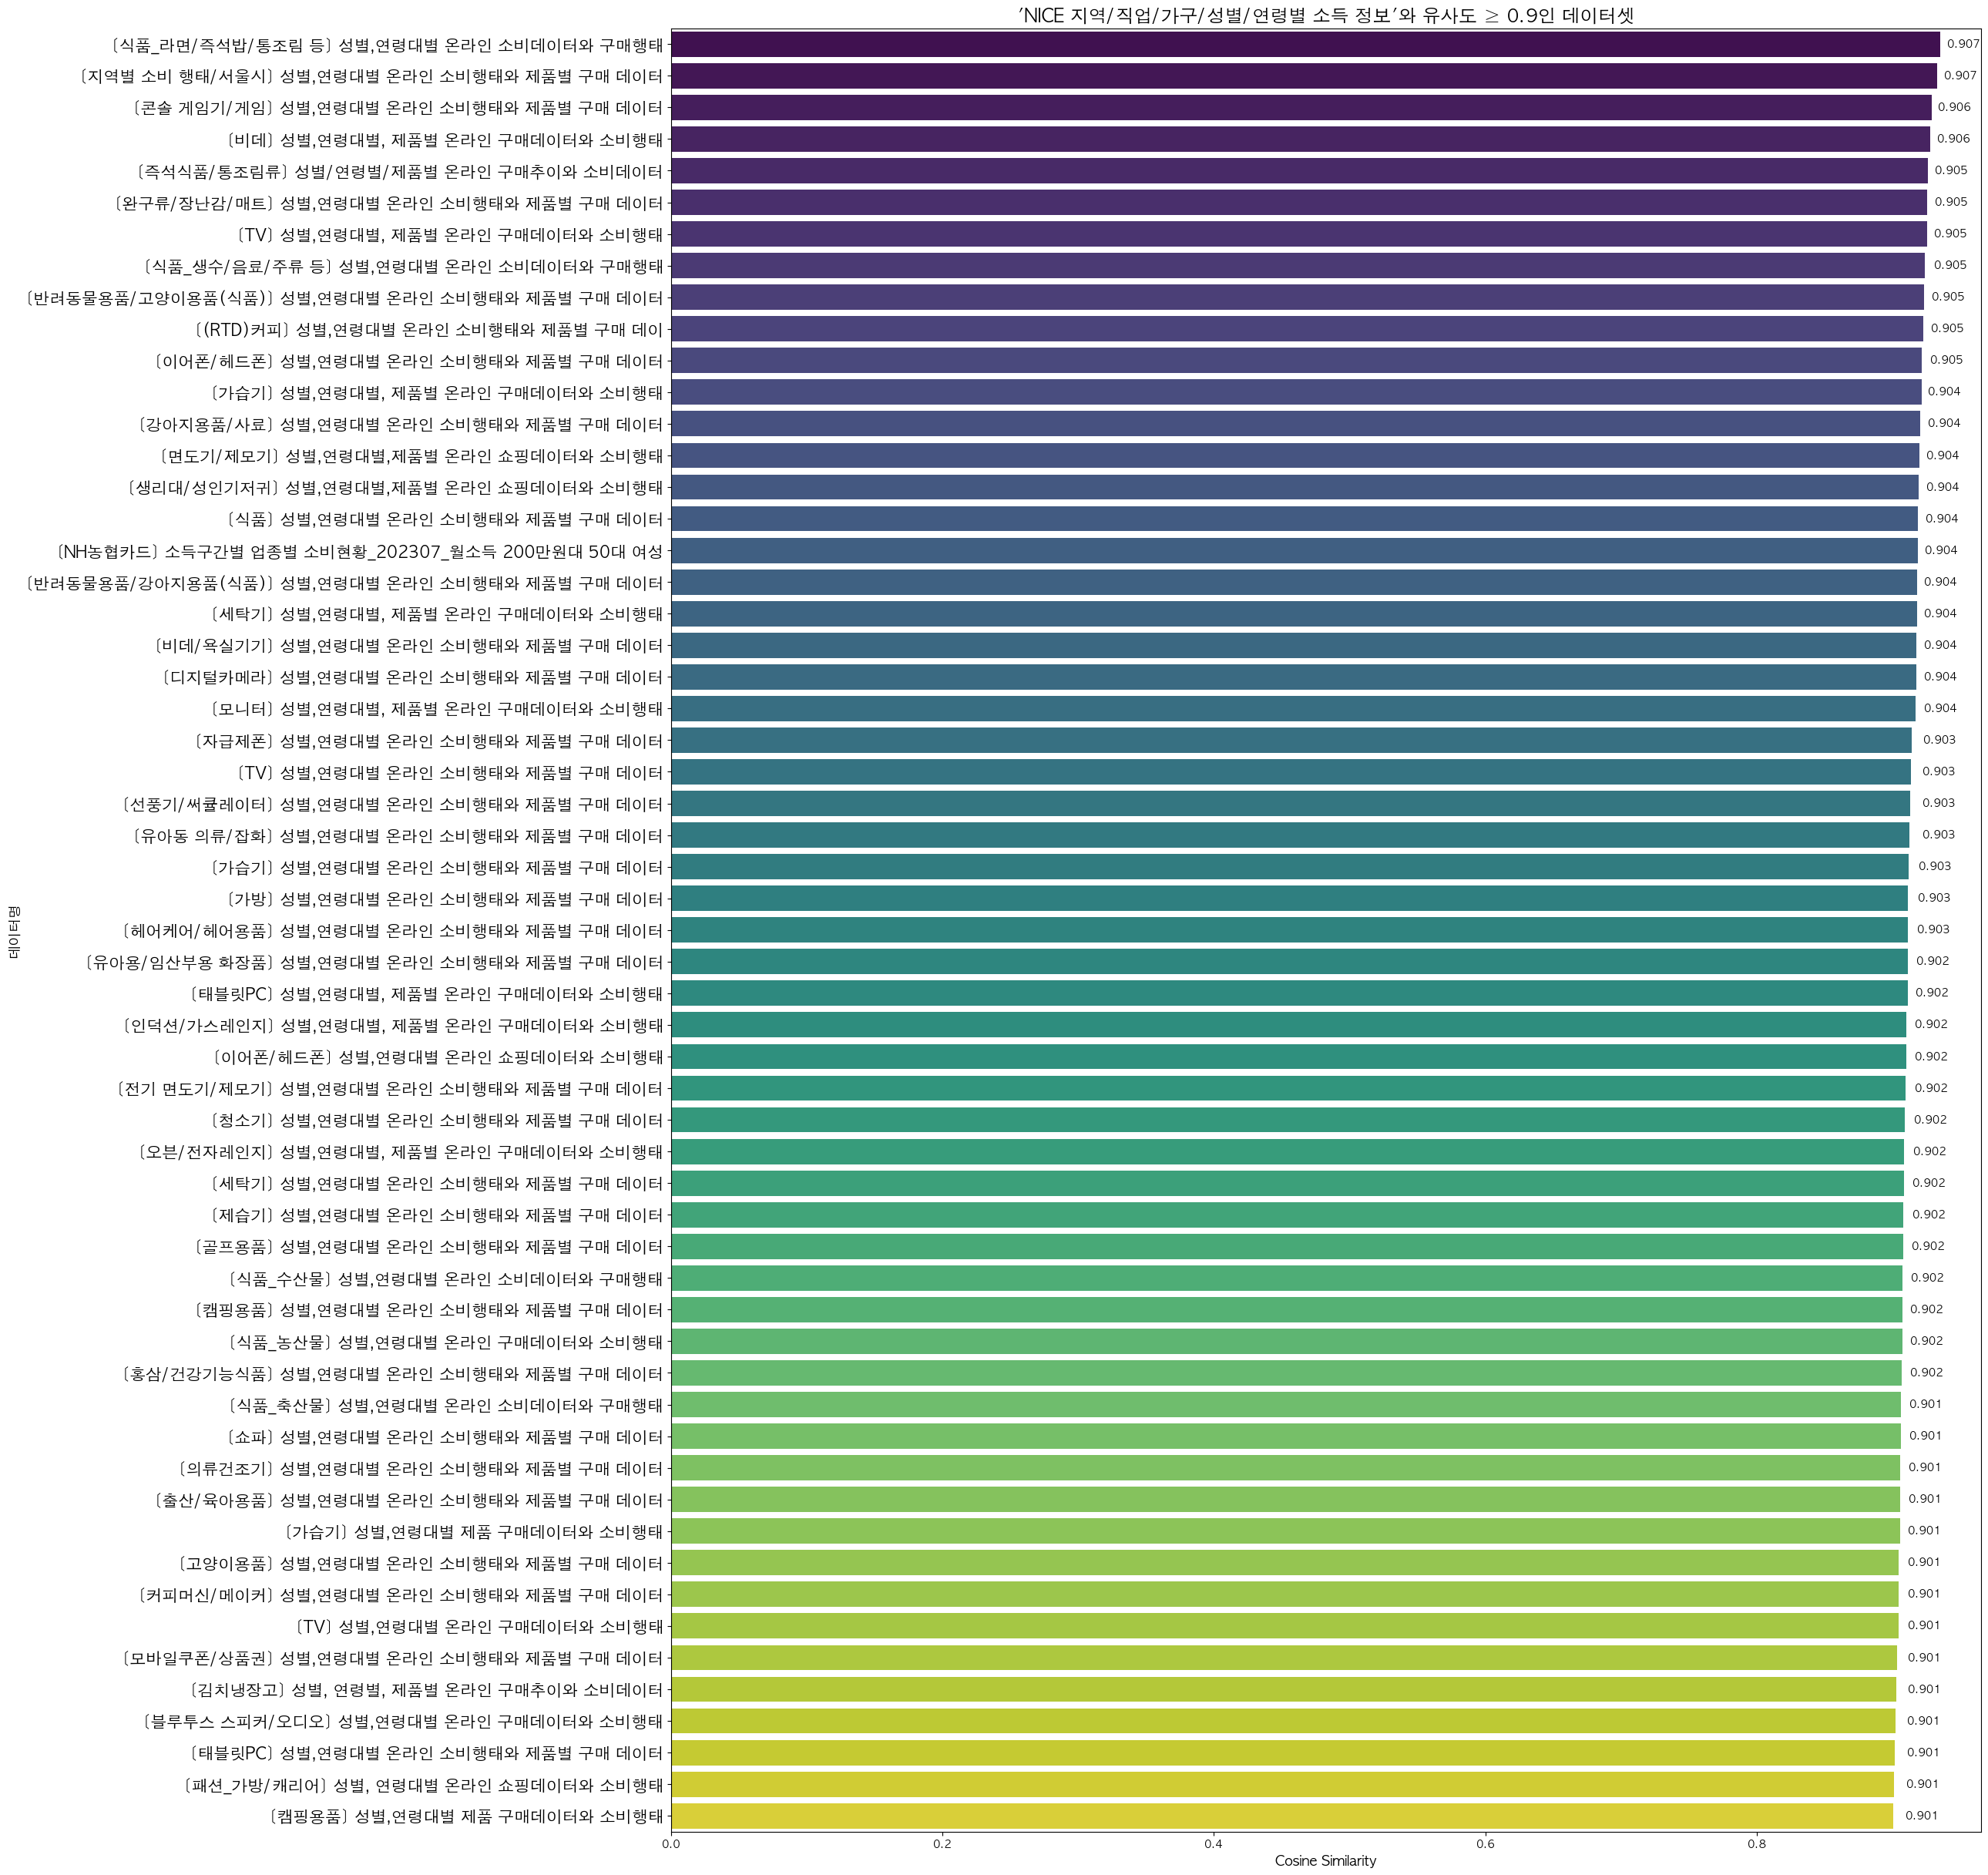

In [44]:
# 유사도 시각화 개선 version

import matplotlib.pyplot as plt
import seaborn as sns

def stretch_similarity(sim):
    return sim if sim < 0.9 else 0.9 + (sim - 0.9) * 5

if not res.empty:
    # 시각화용 복사 & stretch
    res_vis = res.copy()
    res_vis['similarity_stretched'] = res_vis['similarity'].apply(stretch_similarity)
    res_vis = res_vis.sort_values('similarity_stretched', ascending=False)

    print(f"\n 유사도 {threshold} 이상인 데이터셋 (총 {len(res_vis)}건):")
    print(res_vis[['name','description','price','collect_dt','similarity']])

    # 차트
    fig, ax = plt.subplots(figsize=(25, max(4, 0.4 * len(res_vis))))
    sns.barplot(
        data=res_vis,
        x='similarity_stretched',
        y='name',
        palette='viridis',
        ax=ax
    )

    # ← 이 줄이 y축 tick label(데이터명) 폰트 크기를 조정
    ax.tick_params(axis='y', labelsize=15)  

    # 동적 xlim: 최대 stretched 값 + 0.03
    max_st = res_vis['similarity_stretched'].max()
    ax.set_xlim(0, max_st + 0.03)

    # 막대 끝 실제 유사도 텍스트 (클리핑 적용)
    for i, (real, st) in enumerate(zip(res_vis['similarity'], res_vis['similarity_stretched'])):
        ax.text(
            st + 0.005, i, f"{real:.3f}",
            va='center', fontsize=10, clip_on=True
        )

    # 여백 없애기 & 레이아웃 조정
    ax.margins(x=0)
    plt.title(f"'{new_name}'와 유사도 ≥ {threshold}인 데이터셋", fontsize=17)
    plt.xlabel('Cosine Similarity', fontsize=13)
    plt.ylabel('데이터명', fontsize=13)
    plt.tight_layout()
    plt.subplots_adjust(left=0.30, right=0.98, top=0.95, bottom=0.05)
    plt.show()
else:
    print("❗ 유사도 기준 이상의 데이터셋이 없습니다.")

전체 데이터 임베딩 중...

✅ 유사도 0.76 이상인 항목들:


,데이터명,소분류,금액,다운로드 수,제공기관
0,프랜차이즈 카페 판매매출 데이터,NaN,2790000,5,대한제분㈜
1,프랜차이즈 카페 인력운용현황 데이터,NaN,10920000,0,대한제분㈜
2,와인 판매매출 데이터,NaN,1235000,0,대한제분㈜
3,길단위 학원 수,학원,15000000,114,오픈메이트
4,길단위 카페 수,카페,15000000,106,오픈메이트
...,...,...,...,...,...
75,KCB 행정동 기준 소득정보,소득/소비,10000000,19,코리아크레딧뷰로
76,KCB 100m격자 기준 소득정보,소득/소비,20000000,11,코리아크레딧뷰로
77,KCB 집계구 기준 소득정보,소득/소비,15000000,7,코리아크레딧뷰로
78,KCB 행정동 기준 (카드)소비정보,소득/소비,10000000,10,코리아크레딧뷰로


/var/folders/xk/8c55vpcx0494_qk4j8_dj3zh0000gn/T/ipykernel_1197/2346306730.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=filtered_df, x='유사도', y='데이터명', palette='viridis')


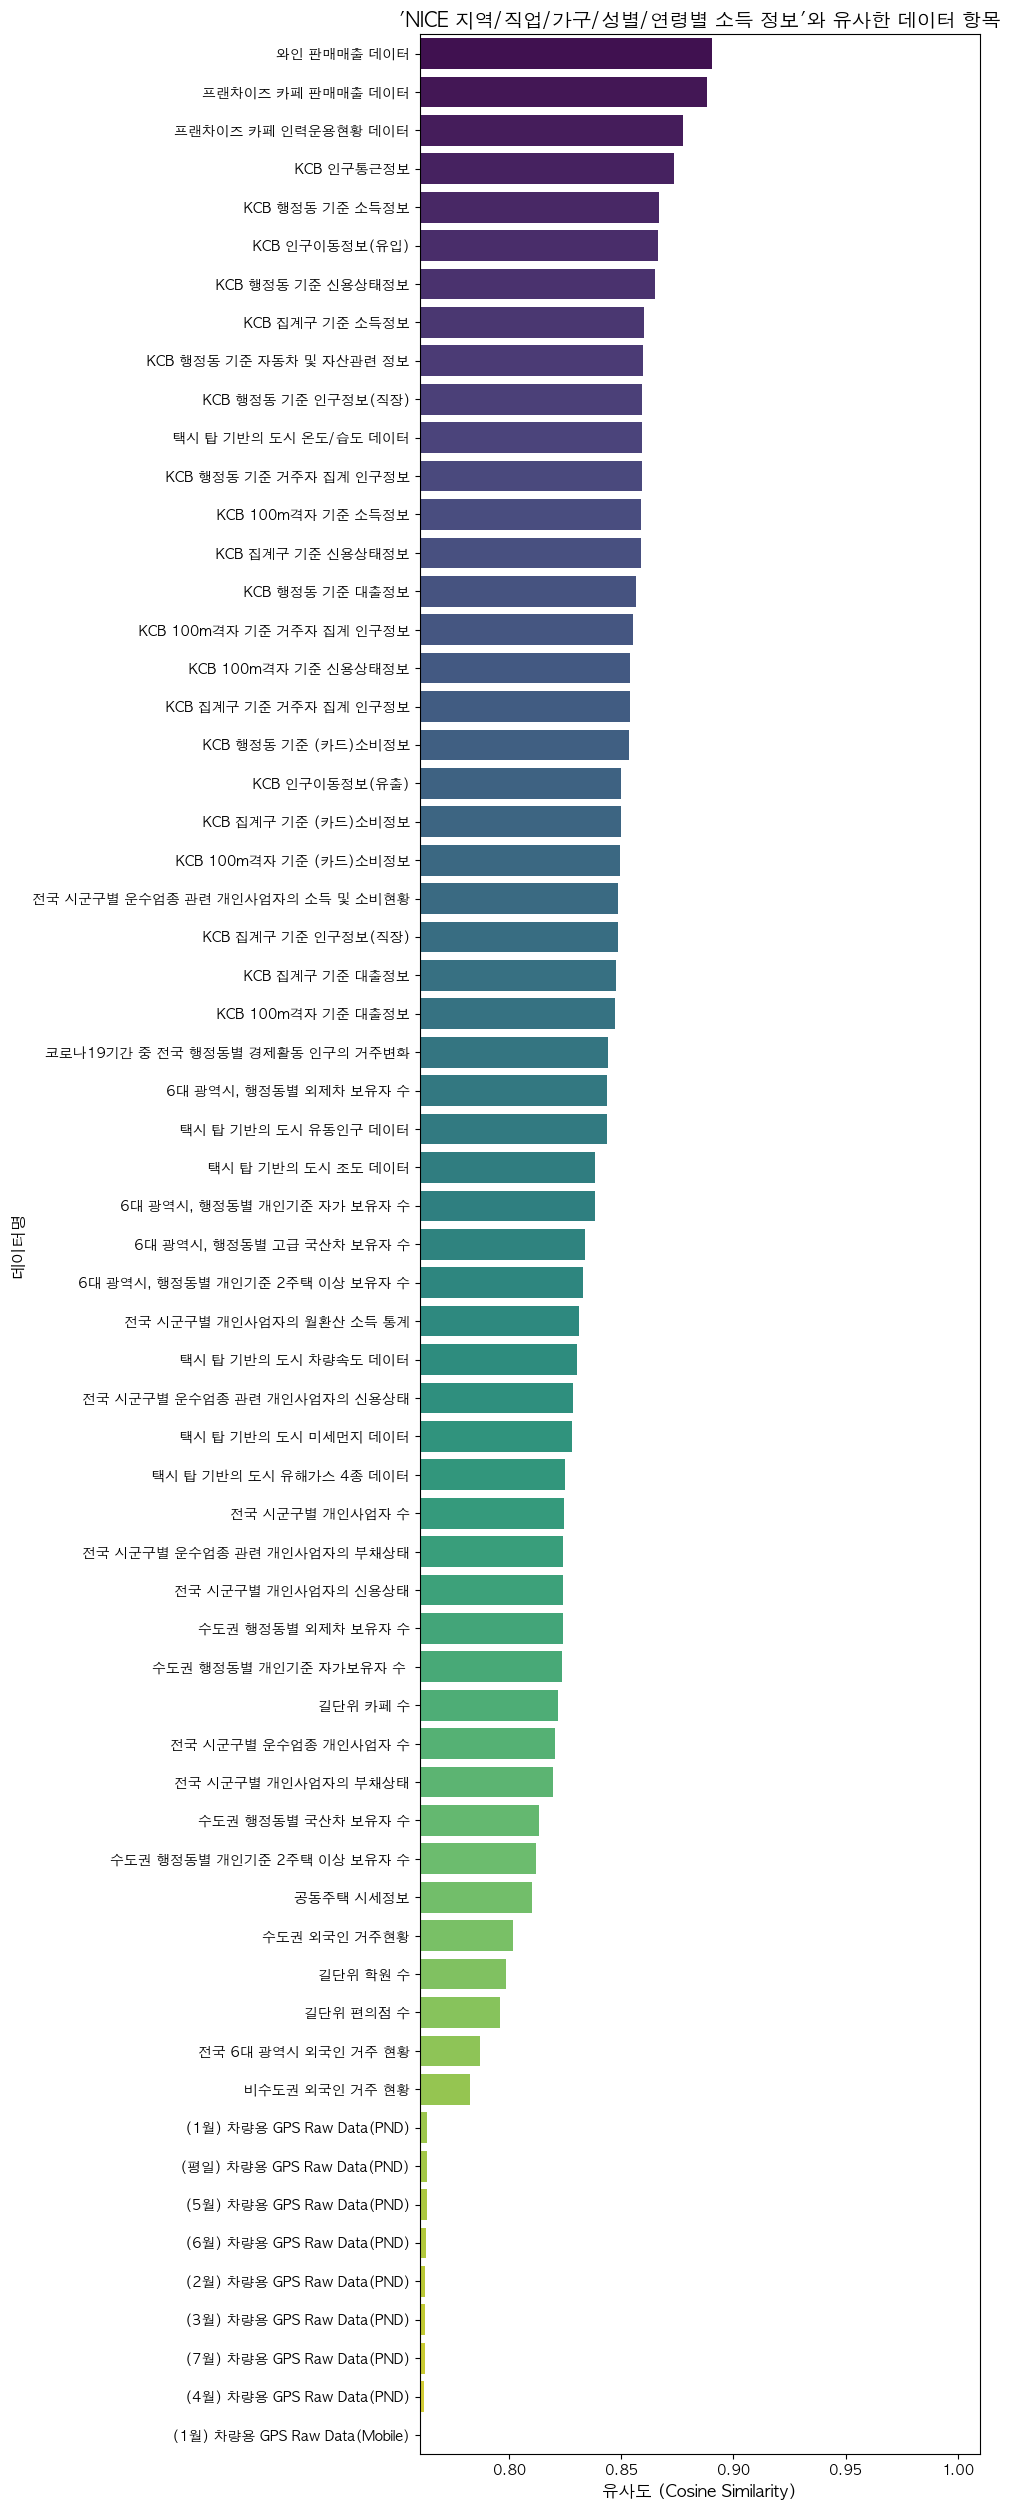

In [ ]:
# 테스트 해보기_3 : 신규 데이터를 전체 데이터들과 유사도 비교 후 추출 !!(이게 젤 괜찮은 것 같음.)

import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드
data = pd.read_csv('/Users/ashmin/Desktop/python workspace/데이터가치인턴/데이터가치평가/국토교통오픈마켓_240624.csv', index_col=0)

# 2. BERT 모델 로드
model_name = "snunlp/KR-BERT-char16424"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# 3. 임베딩 함수 정의
def get_sentence_embedding(sentence):
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze()

# 4. 전체 데이터 임베딩 (데이터명 + 설명)
data['data_text'] = data['데이터명'].astype(str) + ' ' + data['설명'].astype(str)
data_names = data['데이터명'].tolist()
data_texts = data['data_text'].tolist()
print("전체 데이터 임베딩 중...")
embeddings = [get_sentence_embedding(text).numpy() for text in data_texts]

# 5. 신규 데이터 입력!!!!!!
new_name = "NICE 지역/직업/가구/성별/연령별 소득 정보"
new_desc = "지역·직업·가구·성별·연령 등 다양한 인구학적 특성을 기반으로 소득 정보를 제공하며, 시군구부터 집계구 단위까지 세밀한 소득 수준 분석이 가능"
new_text = new_name + ' ' + new_desc
new_embedding = get_sentence_embedding(new_text).numpy()

# 6. 유사도 계산
cosine_sim = cosine_similarity([new_embedding], embeddings)[0]

# 7. 유사도 정리
similarity_df = pd.DataFrame({'데이터명': data_names, '유사도': cosine_sim})
similarity_df = similarity_df.sort_values(by='유사도', ascending=False).reset_index(drop=True)

# 8. 필터링
threshold = 0.76 # 유사도 임계값 설정 (수요자 필요에 따라 조정 가능!!!!) 
filtered_df = similarity_df[similarity_df['유사도'] >= threshold]
filtered_data = data[data['데이터명'].isin(filtered_df['데이터명'])]

# 9. 출력 및 시각화
if not filtered_df.empty:
    print(f"\n✅ 유사도 {threshold} 이상인 항목들:")
    display(filtered_data[['데이터명', '소분류', '금액', '다운로드 수', '제공기관']])

    # 시각화
    plt.figure(figsize=(10, max(6, 0.4 * len(filtered_df))))
    sns.barplot(data=filtered_df, x='유사도', y='데이터명', palette='viridis')
    plt.title(f"'{new_name}'와 유사한 데이터 항목", fontsize=14)
    plt.xlabel('유사도 (Cosine Similarity)', fontsize=12)
    plt.ylabel('데이터명', fontsize=12)
    plt.xlim(threshold, 1.01)
    plt.tight_layout()
    plt.show()
else:
    print("❗ 유사한 데이터가 없습니다.")

/var/folders/xk/8c55vpcx0494_qk4j8_dj3zh0000gn/T/ipykernel_1197/360932495.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='소분류', y='금액', data=filtered_data, order=sorted_categories, palette='Set3')


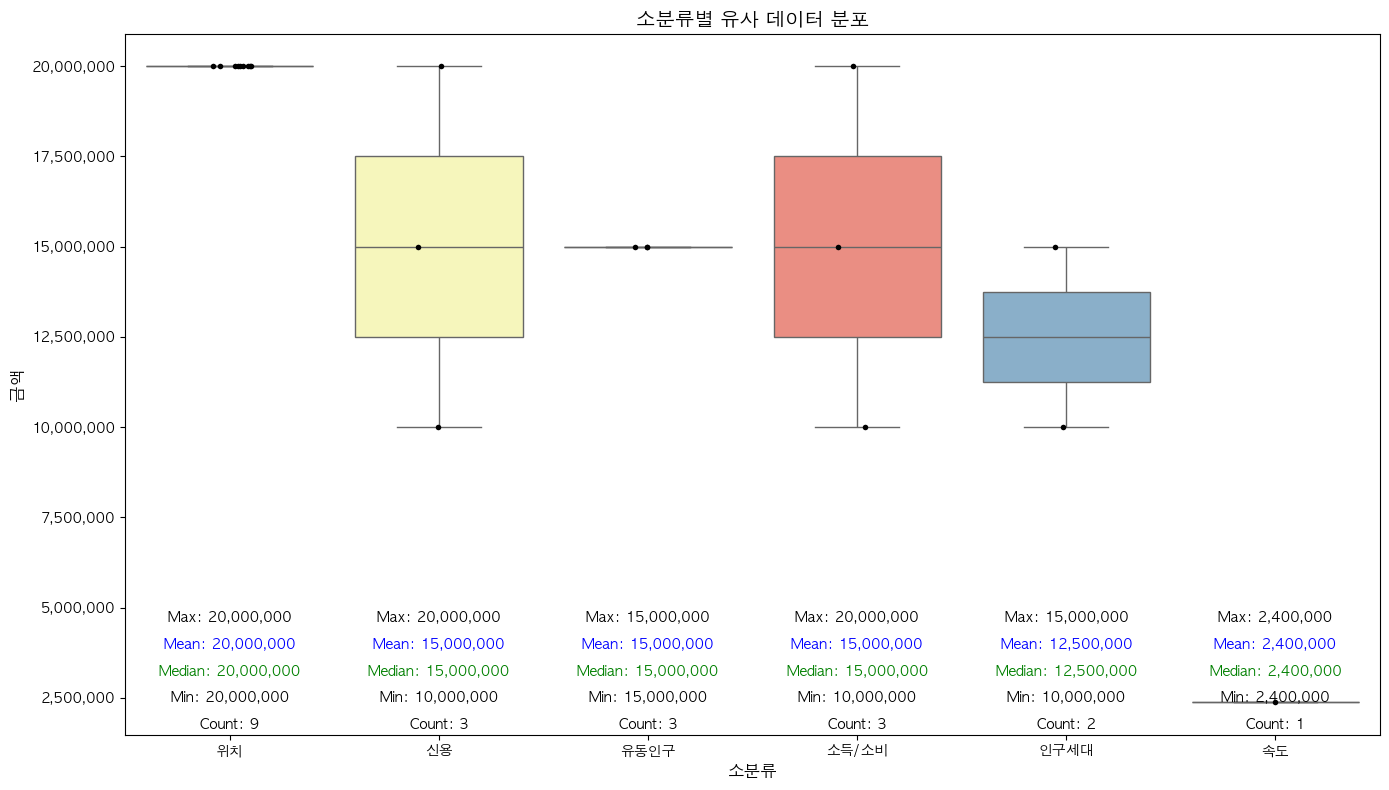

"\n# 10. 시각화\ndef millions(x, pos):\n    return f'{int(x):,}'\n\n\nplt.figure(figsize=(12, 7))\nsorted_categories = filtered_data['소분류'].value_counts().index\n\nax = sns.boxplot(x='소분류', y='금액', data=filtered_data, hue='소분류', palette='Set3', dodge=False)\nsns.stripplot(x='소분류', y='금액', data=filtered_data, jitter=True, color='0.4', dodge=False)\n\n# 통계 계산\ngrouped = filtered_data.groupby('소분류')['금액']\nmins = grouped.min()\nmaxs = grouped.max()\nmeans = grouped.mean()\nmedians = grouped.median()\ncounts = filtered_data['소분류'].value_counts()\n\nx_coords = np.arange(len(sorted_categories))\n\n# 위치 보정 기반 텍스트 추가\nfor i, cat in enumerate(sorted_categories):\n    y_min = mins[cat]\n    y_max = maxs[cat]\n    y_median = medians[cat]\n    y_mean = means[cat]\n    count = counts[cat]\n\n    # y축 범위 비례 기반 위치 조정\n    y_range = max(y_max - y_min, 1)\n    y_max_pos = y_max + y_range * 0.08\n    y_min_pos = y_min - y_range * 0.08\n    y_count_pos = y_min - y_range * 0.13\n    y_mean_pos = y_count_pos 

In [50]:
# 8. 컬럼수 범위 필터링 (예: 기준 12±5)
column_range = 5
filtered_data = filtered_data[(filtered_data['컬럼수'] >= 12 - column_range) & (filtered_data['컬럼수'] <= 12 + column_range)]

# 9. 금액이 숫자인지 확인 후 정수형으로 변환
filtered_data = filtered_data[filtered_data['금액'].notnull()]
filtered_data['금액'] = filtered_data['금액'].astype(int)

# y축 포맷터 함수
def millions(x, pos):
    return f'{int(x):,}'

# 소분류 순서 고정
sorted_categories = filtered_data['소분류'].value_counts().index.tolist()

# 박스플롯 및 스트립플롯
plt.figure(figsize=(14, 8))
ax = sns.boxplot(x='소분류', y='금액', data=filtered_data, order=sorted_categories, palette='Set3')
sns.stripplot(x='소분류', y='금액', data=filtered_data, order=sorted_categories, color='black', jitter=True, size=4)

# 통계값 계산
grouped = filtered_data.groupby('소분류')['금액']
mins = grouped.min()
maxs = grouped.max()
means = grouped.mean()
medians = grouped.median()
counts = filtered_data['소분류'].value_counts()

# y_base: 박스 아래에 고정 텍스트 위치 시작점
y_base = filtered_data['금액'].min() * 0.65
spacing = (filtered_data['금액'].max() - y_base) * 0.04  # 간격

# 하단 고정 텍스트 삽입 (Max → Mean → Median → Min → Count)
for i, cat in enumerate(sorted_categories):
    ax.text(i, y_base + spacing * 4, f"Max: {maxs[cat]:,.0f}", ha='center', va='bottom', fontsize=10, color='black')
    ax.text(i, y_base + spacing * 3, f"Mean: {means[cat]:,.0f}", ha='center', va='bottom', fontsize=10, color='blue')
    ax.text(i, y_base + spacing * 2, f"Median: {medians[cat]:,.0f}", ha='center', va='bottom', fontsize=10, color='green')
    ax.text(i, y_base + spacing * 1, f"Min: {mins[cat]:,.0f}", ha='center', va='bottom', fontsize=10, color='black')
    ax.text(i, y_base + spacing * 0, f"Count: {counts[cat]}", ha='center', va='bottom', fontsize=10, color='black')

# 스타일 설정
plt.title('소분류별 유사 데이터 분포', fontsize=14)
plt.ylabel('금액', fontsize=12)
plt.xlabel('소분류', fontsize=12)
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylim(bottom=y_base * 0.95)  # 하단 공간 확보
plt.tight_layout()
plt.show()

'''
# 10. 시각화
def millions(x, pos):
    return f'{int(x):,}'


plt.figure(figsize=(12, 7))
sorted_categories = filtered_data['소분류'].value_counts().index

ax = sns.boxplot(x='소분류', y='금액', data=filtered_data, hue='소분류', palette='Set3', dodge=False)
sns.stripplot(x='소분류', y='금액', data=filtered_data, jitter=True, color='0.4', dodge=False)

# 통계 계산
grouped = filtered_data.groupby('소분류')['금액']
mins = grouped.min()
maxs = grouped.max()
means = grouped.mean()
medians = grouped.median()
counts = filtered_data['소분류'].value_counts()

x_coords = np.arange(len(sorted_categories))

# 위치 보정 기반 텍스트 추가
for i, cat in enumerate(sorted_categories):
    y_min = mins[cat]
    y_max = maxs[cat]
    y_median = medians[cat]
    y_mean = means[cat]
    count = counts[cat]

    # y축 범위 비례 기반 위치 조정
    y_range = max(y_max - y_min, 1)
    y_max_pos = y_max + y_range * 0.08
    y_min_pos = y_min - y_range * 0.08
    y_count_pos = y_min - y_range * 0.13
    y_mean_pos = y_count_pos - y_range * 0.05
    y_median_pos = y_mean + y_range * 0.03

    # 텍스트 그리기
    ax.text(i, y_max_pos, f'Max\n{y_max:,.0f}', ha='center', va='bottom', fontsize=10, color='black')
    ax.text(i, y_min_pos, f'Min\n{y_min:,.0f}', ha='center', va='top', fontsize=10, color='gray')
    ax.text(i, y_median_pos, f'Median\n{y_median:,.0f}', ha='center', va='bottom', fontsize=10, color='green')
    ax.text(i, y_mean_pos, f'Mean\n{y_mean:,.0f}', ha='center', va='bottom', fontsize=10, color='blue')
    ax.text(i, y_count_pos, f'Count: {count}', ha='center', va='top', fontsize=9, color='black')

# 기타 스타일 설정
plt.title('소분류별 유사 데이터 분포 표시', fontsize=14)
plt.ylabel('금액', fontsize=12)
plt.xlabel('소분류', fontsize=12)
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.legend().remove()
plt.tight_layout()
plt.show()
'''

In [44]:
# 종합 점수 계산
from datetime import datetime

# 1. 날짜 컬럼을 datetime 형식으로 변환 (안 되어 있으면)
data['업데이트 일자'] = pd.to_datetime(data['업데이트 일자'], errors='coerce')
filtered_data['업데이트 일자'] = pd.to_datetime(filtered_data['업데이트 일자'], errors='coerce')

# 2. 평균 업데이트 날짜 계산
average_update_date = filtered_data['업데이트 일자'].mean()

# 3. 가중치 부여 (평균보다 최신이면 0.1, 아니면 0)
filtered_data['update_weight'] = filtered_data['업데이트 일자'].apply(
    lambda x: 0.1 if pd.notnull(x) and x > average_update_date else 0
)

# 4. 유사도 정보와 merge (기존 유사도는 similarity_df에서 가져옴)
filtered_data = filtered_data.merge(filtered_df, on='데이터명', how='left')

# 5. 종합 점수 계산 (예: 유사도 + 업데이트 가중치)
filtered_data['종합점수'] = filtered_data['유사도'] + filtered_data['update_weight']

# 6. 종합점수 기준으로 정렬
filtered_data = filtered_data.sort_values(by='종합점수', ascending=False).reset_index(drop=True)

# 7. 결과 확인
filtered_data[['데이터명', '유사도', '업데이트 일자', 'update_weight', '종합점수']]

,데이터명,유사도,업데이트 일자,update_weight,종합점수
0,프랜차이즈 카페 인력운용현황 데이터,0.877317,2024-03-05,0.1,0.977317
1,KCB 인구통근정보,0.873477,2022-12-06,0.1,0.973477
2,KCB 행정동 기준 소득정보,0.866769,2022-12-06,0.1,0.966769
3,KCB 인구이동정보(유입),0.866132,2022-12-06,0.1,0.966132
4,KCB 집계구 기준 소득정보,0.859881,2022-12-06,0.1,0.959881
5,KCB 행정동 기준 인구정보(직장),0.859404,2022-12-06,0.1,0.959404
6,KCB 100m격자 기준 소득정보,0.858680,2022-12-06,0.1,0.958680
7,KCB 인구이동정보(유출),0.849882,2022-12-06,0.1,0.949882
8,KCB 집계구 기준 인구정보(직장),0.848333,2022-12-06,0.1,0.948333
9,택시 탑 기반의 도시 차량속도 데이터,0.830394,2022-09-05,0.1,0.930394


In [45]:
# 최종 가격은 종합 점수 기준 상위 N개 데이터의 평균 금액으로 설정
# 상위 N개 선택
top_n = 3 # 변경 가능한 값
top_items = filtered_data.head(top_n)

# 금액 평균 계산
predicted_price = top_items['금액'].mean()

# 결과 출력
print(f" 신규 데이터명: '{new_name}'에 대한 데이터 가치 평가 결과")
print(f" 유사데이터 상위 {top_n}개의 평균 금액을 활용한 예상 가격: ₩{predicted_price:,.0f}")

 신규 데이터명: 'NICE 지역/직업/가구/성별/연령별 소득 정보'에 대한 데이터 가치 평가 결과
 유사데이터 상위 3개의 평균 금액을 활용한 예상 가격: ₩11,973,333


***CODE ENDED.***


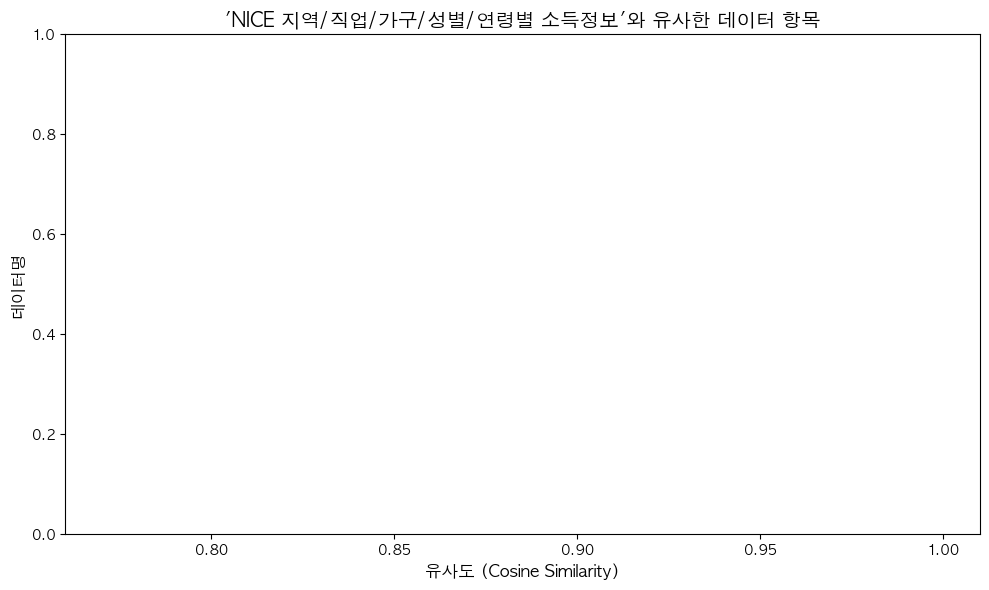

In [84]:
data = pd.read_csv('/Users/ashmin/Desktop/python workspace/데이터가치인턴/데이터가치평가/국토교통오픈마켓_240624.csv', index_col=0)
data_earnings = data[data['소분류'] == '위치'] 

# 입력된 신규 데이터명(new_data_name)과 기존 데이터명들(data_names) 간의 BERT 기반 임베딩 유사도를 계산하여, 유사도가 특정 임계값 이상인 항목들만 필터링하는 전체 흐름
def get_similar_data_bert(new_data_name, data_names): # 새로운 데이터명 하나(new_data_name)과 기존 데이터명 리스트(data_names)를 인자로 받는 함수
    new_data_embedding = get_sentence_embedding(new_data_name).numpy() # 새로운 데이터명을 BERT 임베딩으로 변환 (형태는 numpy 배열)
    cosine_sim = cosine_similarity([new_data_embedding], embeddings)[0] # new_data_embedding과 기존 embeddings (기 저장된 전체 데이터명의 임베딩 리스트) 간의 코사인 유사도 계산.. [0]을 붙인 이유는 결과가 (1, N) 형태의 2D 배열로 나오기 때문
    return cosine_sim

# 유사도 계산 및 데이터프레임 생성
# 데이터명 리스트 정의 (*)
data_names = data_earnings['데이터명'].tolist() # 소분류가 '위치'인 데이터의 데이터 명 추출해오기


# 새로운 데이터명 설정
new_data_name = "NICE 지역/직업/가구/성별/연령별 소득정보"  # 예시 데이터명 

# 해당 데이터명에 대해 기존 데이터들과의 코사인 유사도 계산.
cosine_sim = get_similar_data_bert(new_data_name, data_names)

# 유사도 데이터프레임 생성 (데이터명과 유사도를 하나의 표로 묶습니다)
similarity_df = pd.DataFrame({'데이터명': data_names, '유사도': cosine_sim})

# 유사도 기준 정렬 (내림차순으로 정렬하고 인덱스 재정렬)
similarity_df = similarity_df.sort_values(by='유사도', ascending=False).reset_index(drop=True)
threshold = 0.76 # 유사도가 0.76 이상인 데이터명들만 필터링
filtered_df = similarity_df[similarity_df['유사도'] >= threshold]
filtered_df # 최종적으로 출력된 표는, 신규 데이터명과 높은 유사도를 가진 기존 데이터명 목록입니다.

# 시각화 (*)
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (필요 시)
# plt.rc('font', family='NanumBarunGothic')
# plt.rcParams['axes.unicode_minus'] = False

# 맥북용 폰트 설정
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 시각화: 유사도 Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=filtered_df, x='유사도', y='데이터명', palette='viridis')

plt.title(f"'{new_data_name}'와 유사한 데이터 항목", fontsize=14)
plt.xlabel('유사도 (Cosine Similarity)', fontsize=12)
plt.ylabel('데이터명', fontsize=12)
plt.xlim(threshold, 1.01)
plt.tight_layout()
plt.show()

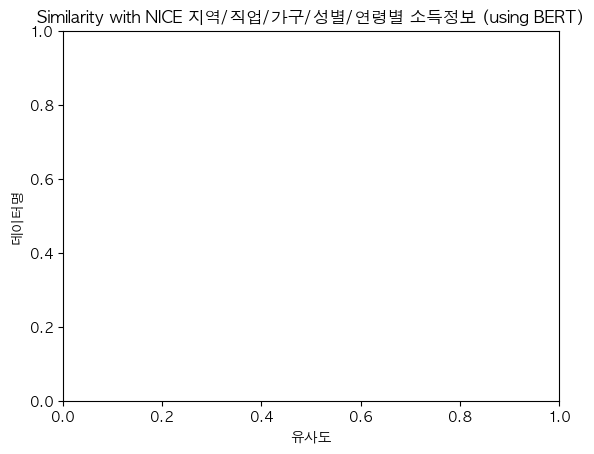

In [82]:
# 상위 N개의 유사 데이터 시각화 (가로 막대 그래프)
# plt.figure(figsize=(10, 8))
sns.barplot(x='유사도', y='데이터명', data=filtered_df, hue='데이터명', palette='viridis')
plt.title(f'Similarity with {new_data_name} (using BERT)')
plt.xlabel('유사도')
plt.ylabel('데이터명')
plt.show()

In [121]:
# 유사도가 일정 기준(threshold 이상)인 데이터명들만 원래의 data_earnings에서 추려내는 작업
# 유사도가 높은 데이터명을 기준으로 원본 데이터셋에서 해당 데이터들의 모든 정보(행)를 가져오는 역할
filtered_data = data_earnings[data_earnings['데이터명'].isin(filtered_df['데이터명'])]
filtered_data

KeyError: '데이터명'

In [122]:
column_range = 5 # 기준점으로부터 ±5 컬럼까지 허용
filtered_data = filtered_data[(filtered_data['컬럼수'] >= 12 - column_range) & (filtered_data['컬럼수'] <= 12 + column_range)] #기준 컬럼 수를 12로 가정하고, 컬럼 수가 7 이상 17 이하인 데이터만 필터링
filtered_data

NameError: name 'filtered_data' is not defined

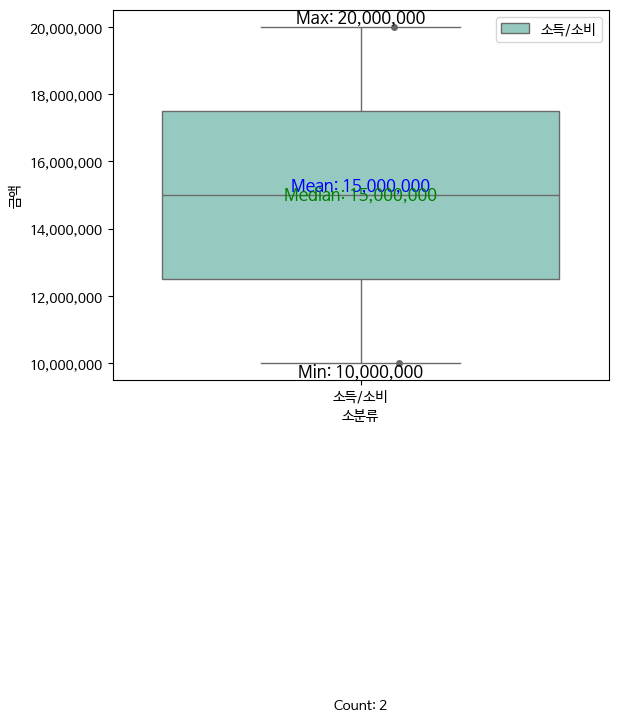

In [ ]:
# 필터링된 데이터(filtered_data)를 기반으로 소분류별 금액 분포를 시각화하고, 각 그룹에 대한 최소값, 최대값, 평균, 중앙값, 개수 정보를 시각적으로 함께 보여주는 박스플롯(Boxplot) + 스트립플롯(Stripplot) 시각화
# 아래 경우 소분류가 소득/소비 인 경우

sorted_categories = filtered_data['소분류'].value_counts().index

ax = sns.boxplot(x='소분류', y='금액', data=filtered_data, hue='소분류', legend=True, palette='Set3')
sns.stripplot(x="소분류", y="금액", data=filtered_data, jitter=True, color="0.4")

# min, max 값 추출 및 텍스트 추가
mins = filtered_data.groupby('소분류')['금액'].min()
maxs = filtered_data.groupby('소분류')['금액'].max()
x_coords = np.arange(len(mins))
for x, min, max in zip(x_coords, mins[sorted_categories], maxs[sorted_categories]):
    ax.text(x, min-1, f'Min: {min:,}', ha='center', va='top', fontsize = 12)
    ax.text(x, max+1, f'Max: {max:,}', ha='center', va='bottom', fontsize = 12)

# count 값 추출 및 텍스트 추가
counts = filtered_data['소분류'].value_counts()
x_coords = np.arange(len(counts))
for x, count in zip(x_coords, counts):
    ax.text(x, 2, f'Count: {count}', ha='center', va='top')

means = filtered_data.groupby('소분류')['금액'].mean()
for x, mean in enumerate(means[sorted_categories]):
    ax.text(x, mean, f'Mean: {mean:,.0f}', ha='center', va='bottom', fontsize=12, color='blue')

# median 값 추출 및 텍스트 추가
medians = filtered_data.groupby('소분류')['금액'].median()
for x, median in enumerate(medians[sorted_categories]):
    ax.text(x, median, f'Median: {median:,.0f}', ha='center', va='center', fontsize=12, color='green')

plt.figure(figsize=(20, 10)) # (*)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.xticks(rotation=0)
plt.show()

	1.	박스플롯 생성 (sns.boxplot)
	•	x='소분류', y='금액' 값을 기준으로 금액 분포 시각화
	•	hue='소분류'를 주면 색이 자동 분리됨
	2.	스트립플롯 추가 (sns.stripplot)
	•	개별 데이터 포인트도 산포도로 보여줌 (분포 확인)
	3.	최소/최대값 텍스트 표시 (ax.text)
	•	min, max 위치에 각각 텍스트로 표시 (Min: 000, Max: 000)
	4.	Count 텍스트 표시
	•	각 소분류당 개수 표시 (x축 근처 2 높이에 표시)
	5.	평균/중앙값 표시
	•	Mean: 000, Median: 000 형태로 평균은 파란색, 중앙값은 초록색으로 표시
	6.	y축 단위 조정
	•	FuncFormatter(millions)를 사용해 y축 금액에 천 단위 쉼표 등을 적용

True

In [ ]:
filtered_data['업데이트 일자'].apply(lambda x: 0.1 if x > average_update_date else 0) # 평균 업데이트 날짜보다 이후이면 0.1, 아니면 0 반환

75    0
76    0
Name: 업데이트 일자, dtype: int64

In [ ]:
from datetime import datetime

# 기준 일자와 평균 일자 비교
update_date_threshold = datetime.strptime("2023-04-14", "%Y-%m-%d")
filtered_data['업데이트 일자'] = pd.to_datetime(filtered_data['업데이트 일자'])
display(filtered_data)
average_update_date = filtered_data['업데이트 일자'].mean()
#조건 만족 시 가중치 부여
update_date_point = (update_date_threshold > average_update_date) * 0.1
print(f"데이터 최신성 가점 : ", {update_date_point}) # 기준일이 평균보다 최신일 경우 가점 주기

,데이터명,설명,태그,제공기관,제공형식,수정일,다운로드 수,금액,대분류,중분류,소분류,컬럼수,제공형태,제공포맷,업데이트 일자,업데이트 가점
75,KCB 행정동 기준 소득정보,"KCB에 등록된 만18세 이상, 내국인의 신용정보를 행정동 단위로 집계한 소득정보로...",융합,코리아크레딧뷰로,NaN,2020-09-05,19,10000000,도시,재무,소득/소비,16,정형,CSV,2022-12-06,0
76,KCB 100m격자 기준 소득정보,"KCB에 등록된 만18세 이상, 내국인의 신용정보를 국토지리정보원 100m 격자 단...",융합,코리아크레딧뷰로,NaN,2020-09-05,11,20000000,도시,재무,소득/소비,16,정형,CSV,2022-12-06,0


데이터 최신성 가점 :  {0.1}


In [ ]:
#최종 가격 계산
final_cost = 15000000 * (1 + 0.1 + 0.1) # (평균?) 가격 + 가점 10% + 가점 10% = 총 20% 상승
print(final_cost)

18000000.000000004


신규 데이터명과 유사한 기존 데이터들을 필터링한 뒤, 그들의 금액 특성을 시각화하고, 최종 가격을 가점 기준으로 계산하는 분석 파이프라인